In [2]:
from modpath import modify_path

modify_path()

In [3]:
import pathlib

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import PartialDependenceDisplay, permutation_importance
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder


from src import model, pipelines, processing, scoring

/mnt/d/Documents/Coding/ML/Airline/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
DATA_DIR = pathlib.Path('../data')

In [5]:
data = pd.read_csv(DATA_DIR.joinpath('train.csv'))
test = pd.read_csv(DATA_DIR.joinpath('test.csv'))

# Exploratory Data Analysis

In [6]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 25 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Unnamed: 0                         103904 non-null  int64  
 1   id                                 103904 non-null  int64  
 2   Gender                             103904 non-null  str    
 3   Customer Type                      103904 non-null  str    
 4   Age                                103904 non-null  int64  
 5   Type of Travel                     103904 non-null  str    
 6   Class                              103904 non-null  str    
 7   Flight Distance                    103904 non-null  int64  
 8   Inflight wifi service              103904 non-null  int64  
 9   Departure/Arrival time convenient  103904 non-null  int64  
 10  Ease of Online booking             103904 non-null  int64  
 11  Gate location                      103904 non-null

In [7]:
test.info()

<class 'pandas.DataFrame'>
RangeIndex: 25976 entries, 0 to 25975
Data columns (total 25 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Unnamed: 0                         25976 non-null  int64  
 1   id                                 25976 non-null  int64  
 2   Gender                             25976 non-null  str    
 3   Customer Type                      25976 non-null  str    
 4   Age                                25976 non-null  int64  
 5   Type of Travel                     25976 non-null  str    
 6   Class                              25976 non-null  str    
 7   Flight Distance                    25976 non-null  int64  
 8   Inflight wifi service              25976 non-null  int64  
 9   Departure/Arrival time convenient  25976 non-null  int64  
 10  Ease of Online booking             25976 non-null  int64  
 11  Gate location                      25976 non-null  int64  
 12  F

In [8]:
# Check for missing values
for d in [data, test]:
    for col in d.columns:
        if d[col].isna().sum() > 0:
            print(f'{col} has {d[col].isna().sum()} missing values')
    print()

Arrival Delay in Minutes has 310 missing values

Arrival Delay in Minutes has 83 missing values



## Arival Delays

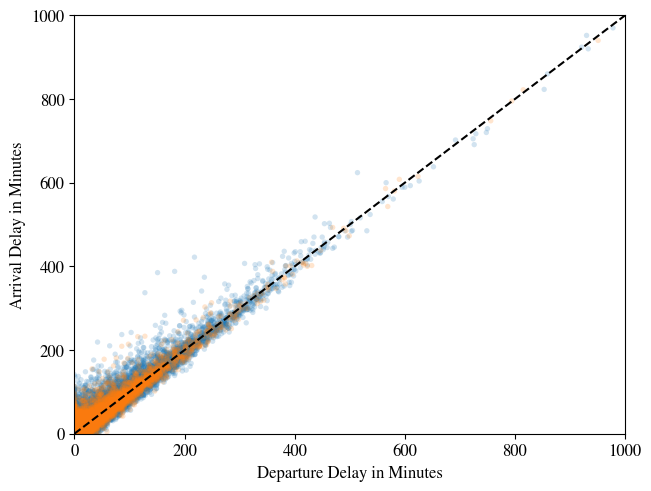

In [9]:
fig, ax = plt.subplots(constrained_layout=True)
for d in [data, test]:
    sns.scatterplot(
        data=d,
        x='Departure Delay in Minutes',
        y='Arrival Delay in Minutes',
        s=15,
        edgecolor='none',
        alpha=0.2,
    )
ax.plot([0, 1], [0, 1], transform=ax.transAxes, color='k', linestyle='--')
ax.set(xlim=(0, 1000), ylim=(0, 1000))
plt.show()

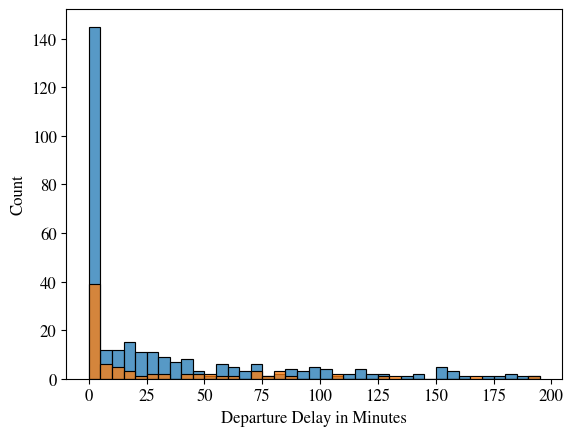

In [10]:
for d in [data, test]:
    sns.histplot(
        data=d[d['Arrival Delay in Minutes'].isna()],
        x='Departure Delay in Minutes',
        bins=np.arange(0, 200, 5),
    )

In [11]:
lam = lambda x: print(
    f'{(x.loc[x['Arrival Delay in Minutes'].isna(), 'Departure Delay in Minutes'] == 0).sum():>3}'
    f' of {x['Arrival Delay in Minutes'].isna().sum():>3}'
    f' missing arrivals have departure delays of 0 minutes.'
)
lam(data)
lam(test)

116 of 310 missing arrivals have departure delays of 0 minutes.
 31 of  83 missing arrivals have departure delays of 0 minutes.


Since there is a high correlation between arrival and departure delays, we will assume the few (< 1%) missing arrival delay values are equal to the departure delay values.

In [12]:
data = processing.impute_arrival_delays(data)
test = processing.impute_arrival_delays(test)
print(
    data['Arrival Delay in Minutes'].isna().sum(),
    test['Arrival Delay in Minutes'].isna().sum(),
)

0 0


## EDA Continued

In [13]:
# Check if all ids are unique
print(data['id'].nunique() == len(data), test['id'].nunique() == len(test))

True True


In [14]:
# Check options for non-numeric columns
for d in [data, test]:
    for col in d.columns:
        if d[col].dtype == 'str':
            print(f'{col} unique values: {list(d[col].unique())}')
    print()

Gender unique values: ['Male', 'Female']
Customer Type unique values: ['Loyal Customer', 'disloyal Customer']
Type of Travel unique values: ['Personal Travel', 'Business travel']
Class unique values: ['Eco Plus', 'Business', 'Eco']
satisfaction unique values: ['neutral or dissatisfied', 'satisfied']

Gender unique values: ['Female', 'Male']
Customer Type unique values: ['Loyal Customer', 'disloyal Customer']
Type of Travel unique values: ['Business travel', 'Personal Travel']
Class unique values: ['Eco', 'Business', 'Eco Plus']
satisfaction unique values: ['satisfied', 'neutral or dissatisfied']



In [15]:
numeric_cols = [
    'Age',
    'Flight Distance',
    'Departure Delay in Minutes',
    'Arrival Delay in Minutes',
]
categorical_cols = ['Gender', 'Customer Type', 'Type of Travel', 'Class']

# These columns are all ratings from 0-5 or 1-5
rated_cols = [
    'Inflight wifi service',
    'Departure/Arrival time convenient',
    'Ease of Online booking',
    'Gate location',
    'Food and drink',
    'Online boarding',
    'Seat comfort',
    'Inflight entertainment',
    'On-board service',
    'Leg room service',
    'Baggage handling',
    'Checkin service',
    'Inflight service',
    'Cleanliness',
]

Reformat the data by converting satisfaction to bool, categorical columns into category dtypes, and dropping unused columns

In [16]:
df = processing.reformat_data(data, categorical_cols=categorical_cols)
df_test = processing.reformat_data(test, categorical_cols=categorical_cols)

for d in [df, df_test]:
    satisfied_frac = d['satisfaction'].sum() / len(d)
    print(f'Fraction of satisfied customers: {satisfied_frac:.2%}')
    print(d['satisfaction'].value_counts())
    print()

Fraction of satisfied customers: 43.33%
satisfaction
False    58879
True     45025
Name: count, dtype: int64

Fraction of satisfied customers: 43.90%
satisfaction
False    14573
True     11403
Name: count, dtype: int64



## Visualizations

Plot histograms of numeric columns separated by satisfied and non-satisfied customers.

### Numeric Features

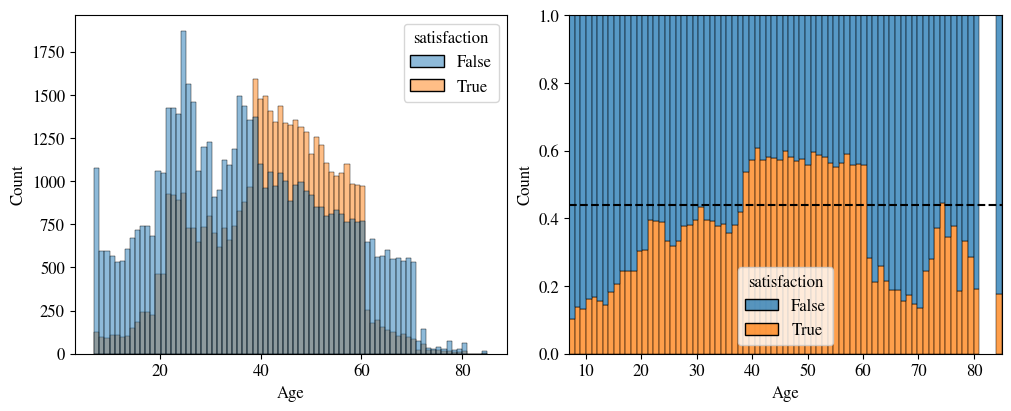

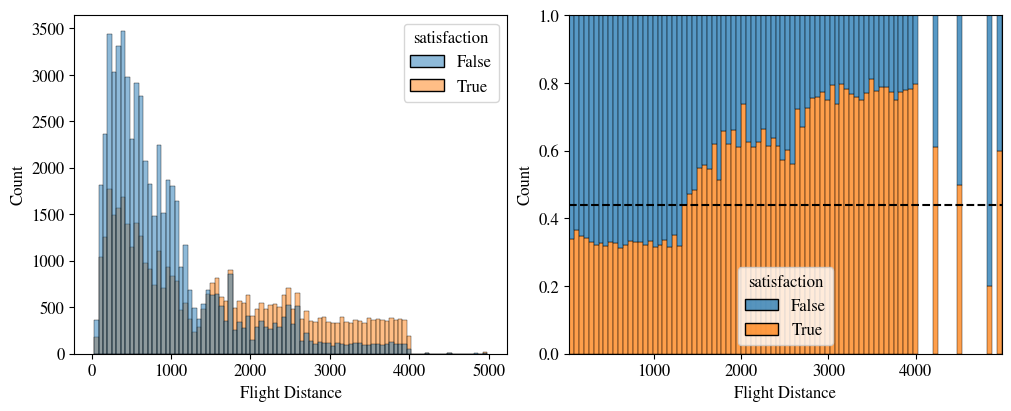

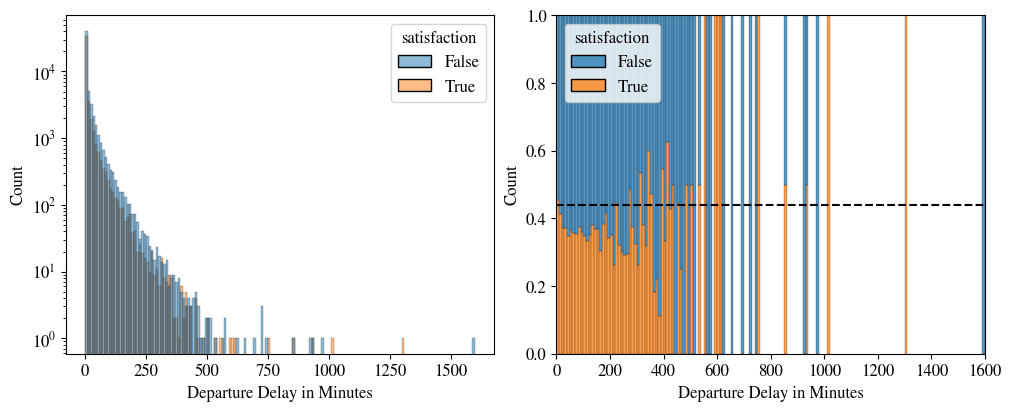

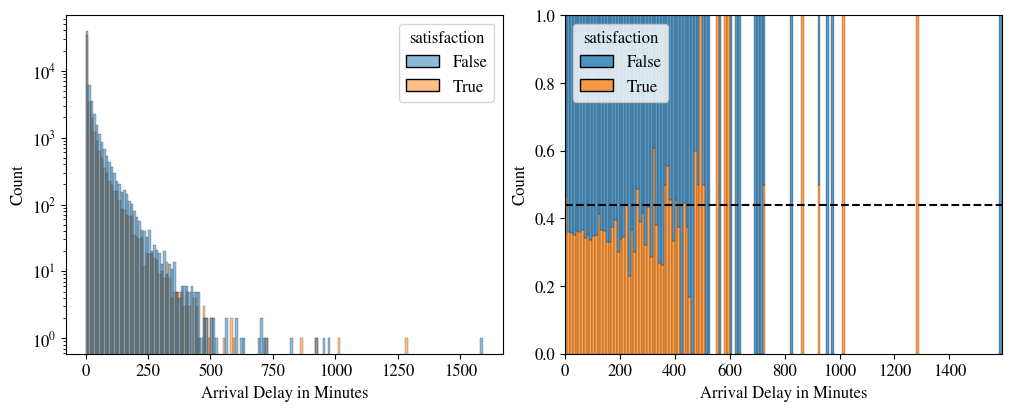

In [25]:
satisfied = df['satisfaction']

for i, col in enumerate(numeric_cols):
    fig, ax = plt.subplots(figsize=(10, 4), ncols=2, constrained_layout=True)
    if i > 1:
        bins = np.arange(0, df[col].max() + 10, 10)
        sns.histplot(x=df[col], bins=bins, hue=satisfied, ax=ax[0])
        sns.histplot(x=df[col], bins=bins, multiple='fill', hue=satisfied, ax=ax[1])
        ax[0].set(yscale='log')
        ax[1].axhline(y=satisfied_frac, color='k', linestyle='--')
    else:
        sns.histplot(data=df, x=col, hue='satisfaction', ax=ax[0])
        sns.histplot(data=df, x=col, multiple='fill', hue='satisfaction', ax=ax[1])
        ax[1].axhline(y=satisfied_frac, color='k', linestyle='--')

    plt.show()

Observations:
1. Satisfaction rate is generally higher for passengers between the ages of 40 to 60 years old.
    - This may be the result of other factors. Passengers in this age range may more likely be flying in business class or more likely flying for business reasons. Flying in business class would probably increase satisfaction, and flying at a company's expense rather than their own may also increase satisfaction.
2. Satisfaction rate is generally higher for passengers taking longer flights.
    - Passengers may book more favorable flights when they know it's going to be a longer journey.
    - Satisfaction may be affected by the passengers' general feelings of the trips they are taking. Longer trips may correspond to going to a new, faraway location, perhaps for a vacation, which makes them feel more positively about their flight experience.
3. Satisfaction rate does not appear to depend much on how long departure or arrival delays are.
    - Satisfaction rate is notably higher when there are no-to-short (< 10 mins) delays and drops to a somewhat consistent level when there are longer delays.

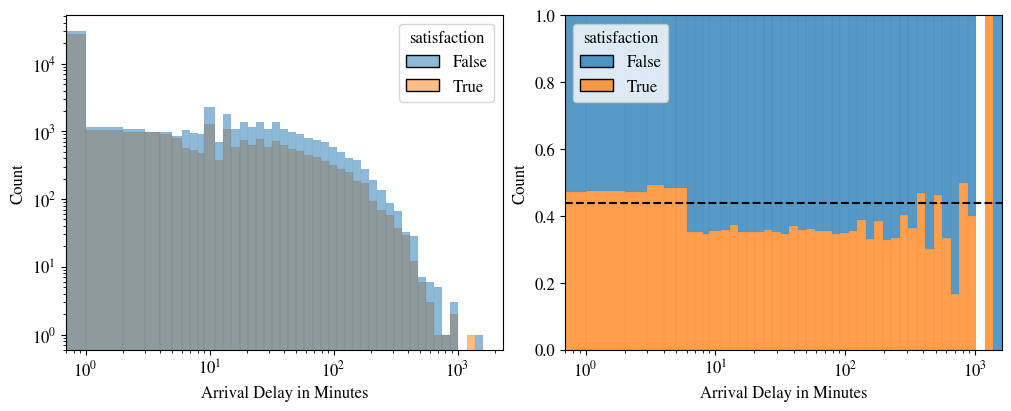

In [17]:
cts, bins = np.histogram(
    df['Arrival Delay in Minutes'].dropna(), bins=np.logspace(0, np.log10(1600), 50)
)
bins = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9] + list(bins[bins > 11])

fig, ax = plt.subplots(figsize=(10, 4), ncols=2, constrained_layout=True)
ret = sns.histplot(x=df['Arrival Delay in Minutes'], bins=bins, hue=satisfied, ax=ax[0])
sns.histplot(
    x=df['Arrival Delay in Minutes'],
    bins=bins,
    multiple='fill',
    hue=satisfied,
    ax=ax[1],
)
ax[0].set(yscale='log', xscale='log')
ax[1].set(xscale='log')
ax[1].axhline(y=satisfied_frac, color='k', linestyle='--')
plt.show()

There's a dropoff in satisfaction rate once delays exceed about 6 minutes.

### Rating Features

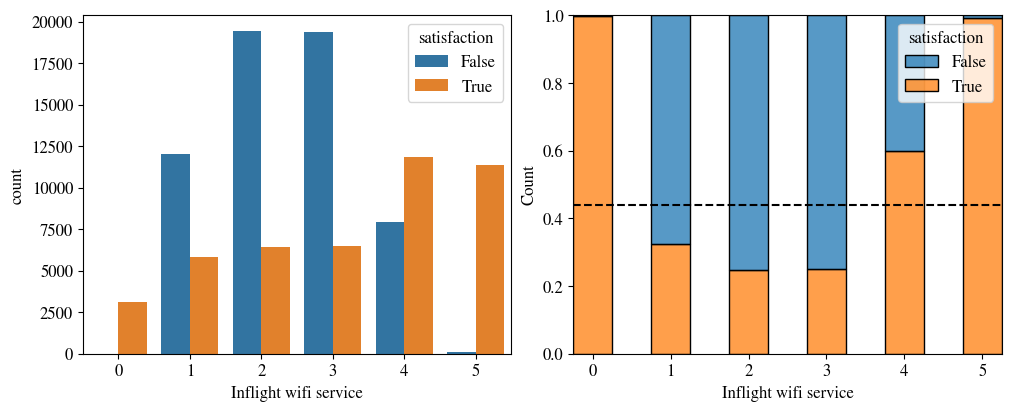

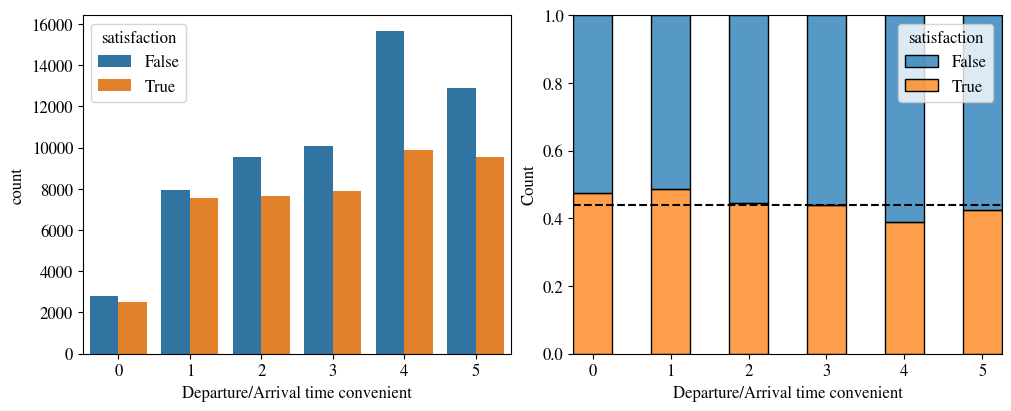

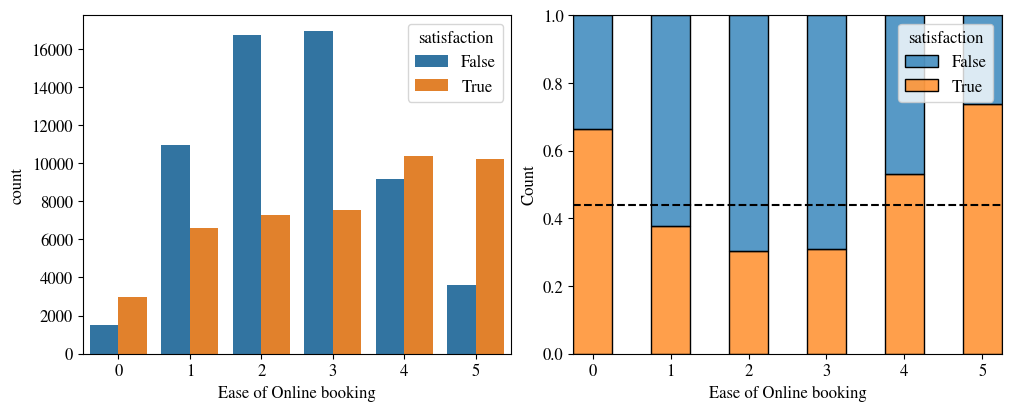

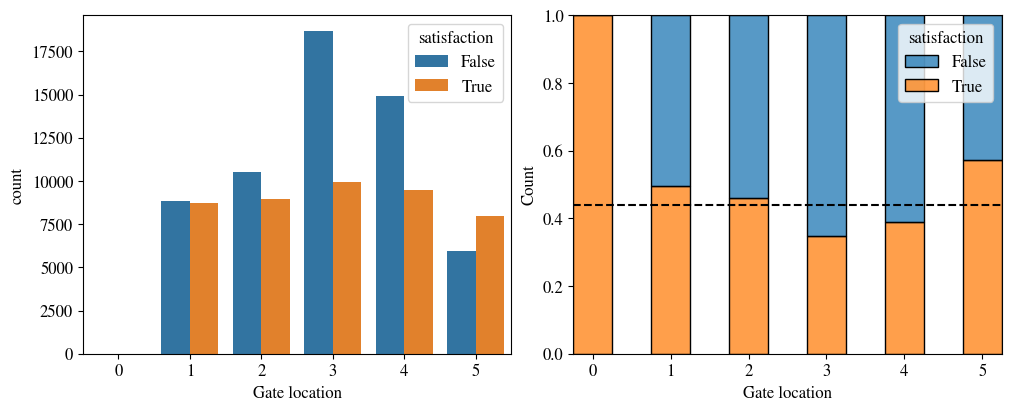

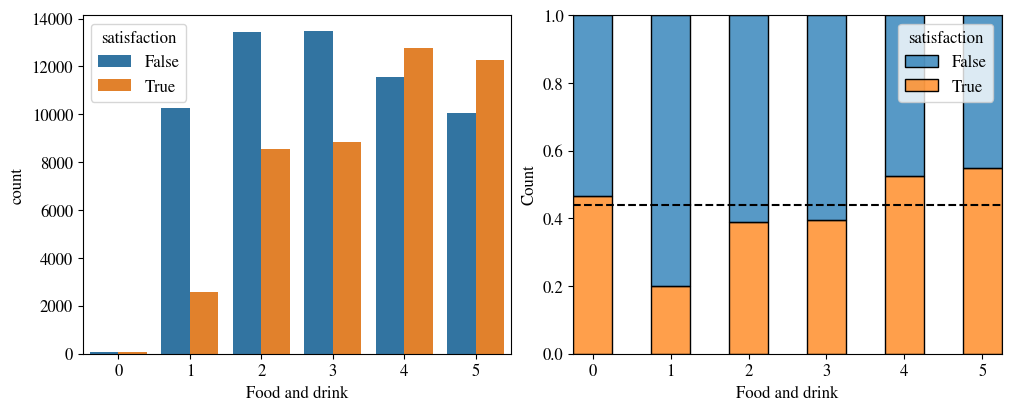

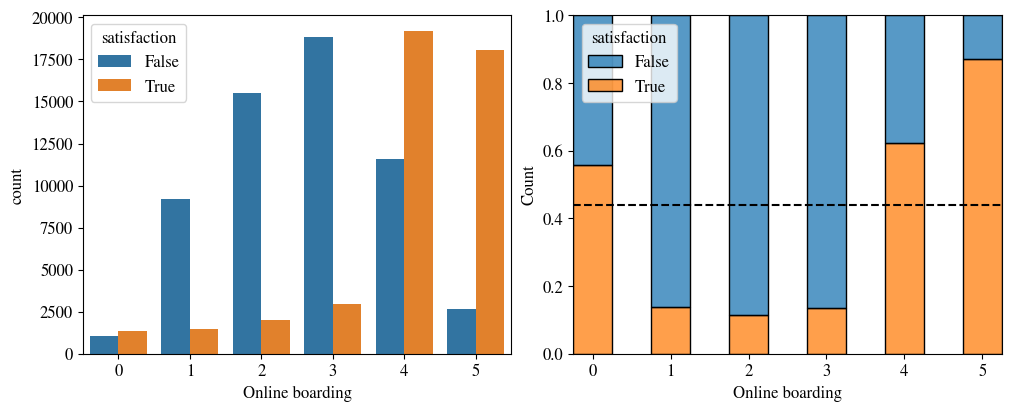

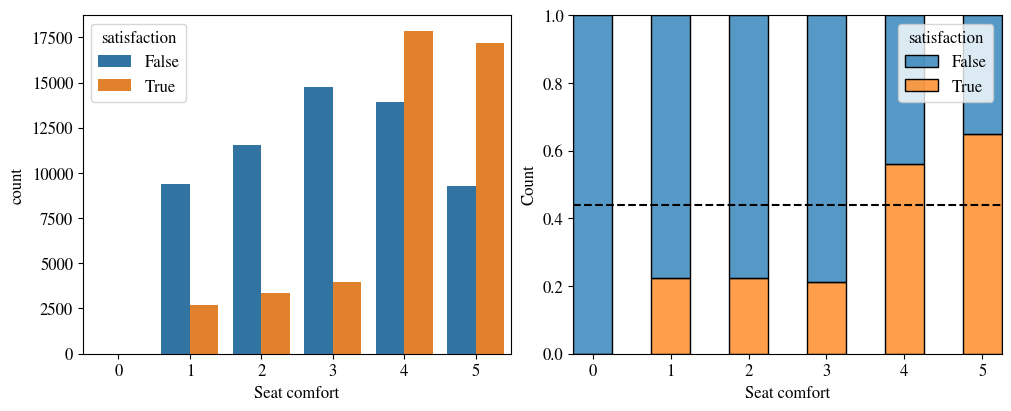

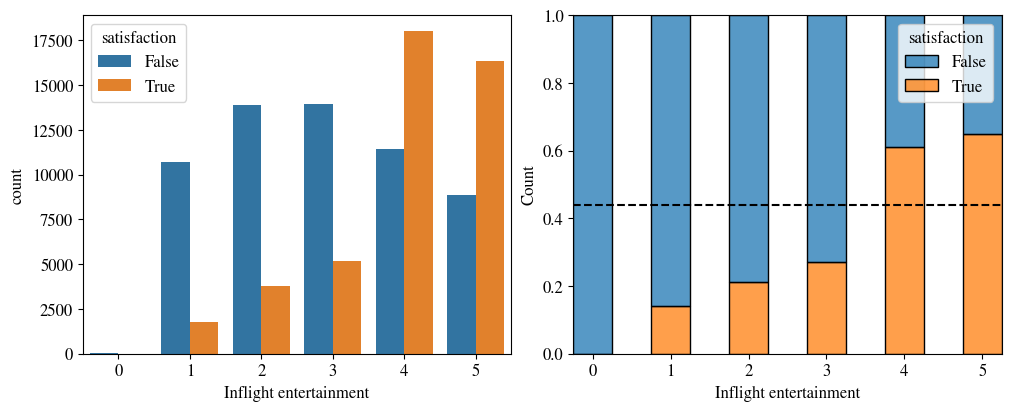

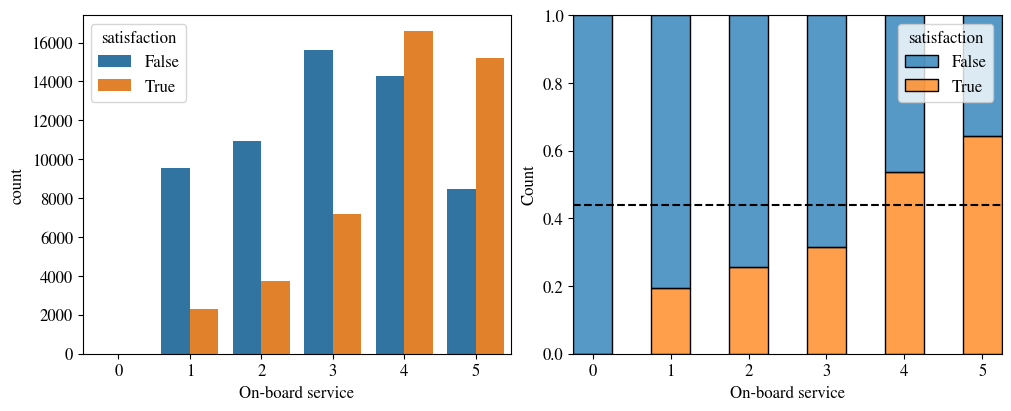

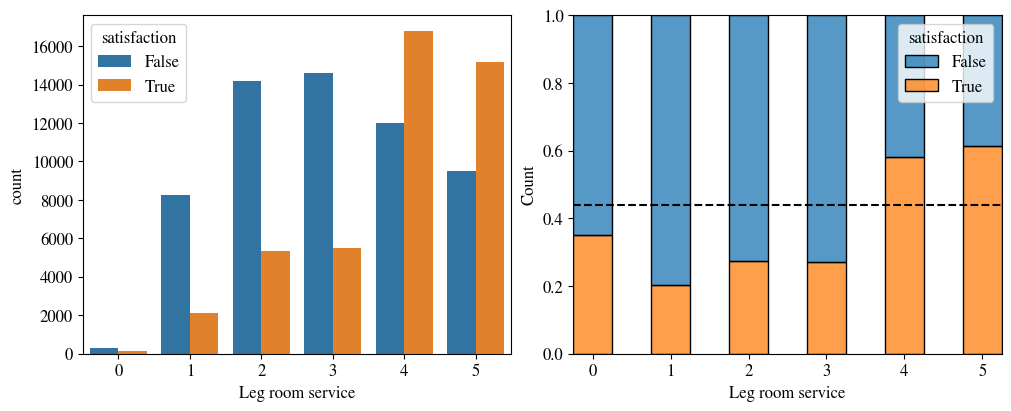

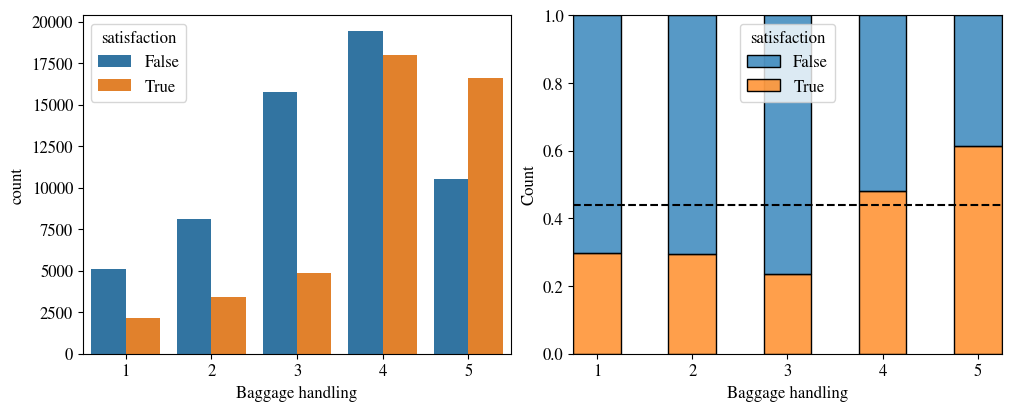

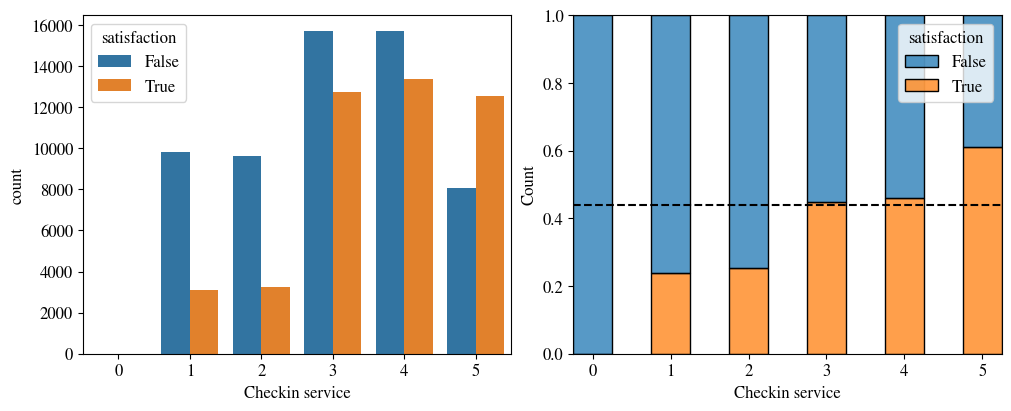

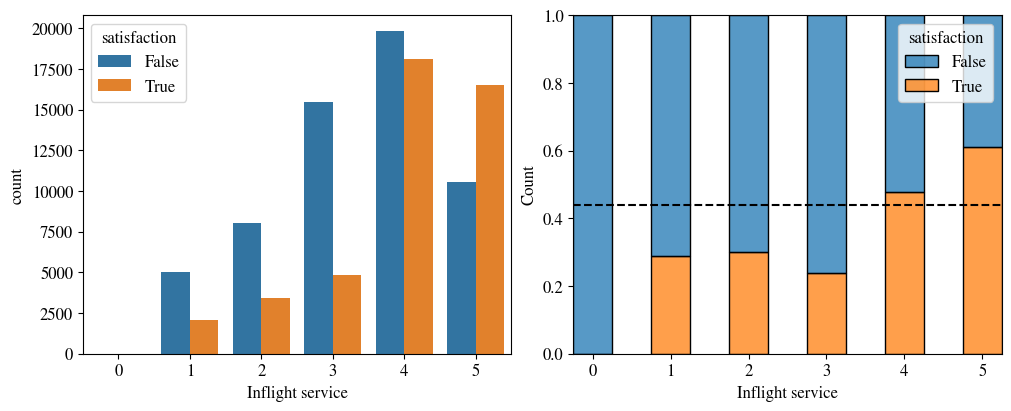

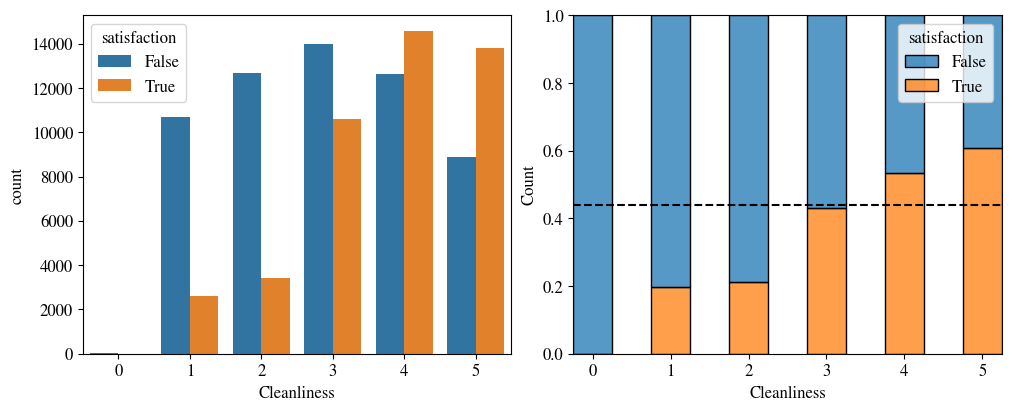

In [18]:
for i, col in enumerate(rated_cols):
    fig, ax = plt.subplots(figsize=(10, 4), ncols=2, constrained_layout=True)
    sns.countplot(data=df, x=col, hue='satisfaction', ax=ax[0])
    sns.histplot(
        data=df,
        x=col,
        multiple='fill',
        hue='satisfaction',
        discrete=True,
        shrink=0.5,
        ax=ax[1],
    )
    ax[1].axhline(y=satisfied_frac, color='k', linestyle='--')
    plt.show()

Observations:

1. As would probably be expected, satisfaction rate tends to increase as ratings increase.

2. It's unclear what 0 means here. Given the generally low counts the way 0s are distributed, it seems that it may be "N/A" rather than a true 0 rating.

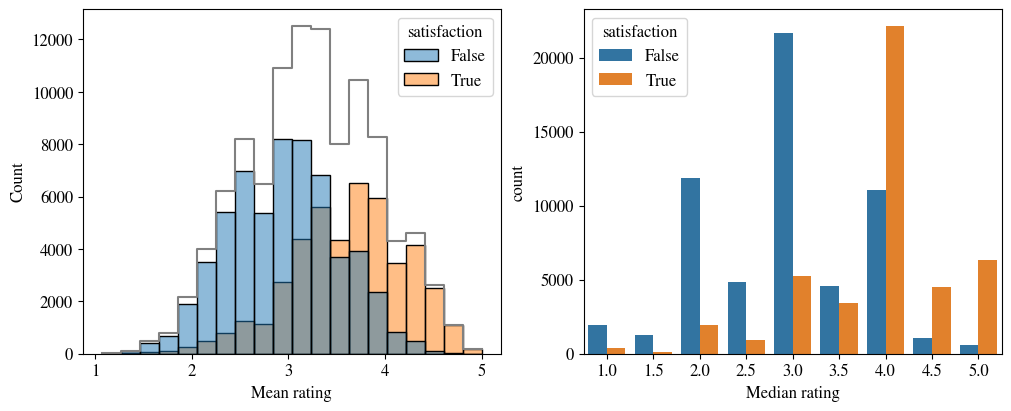

In [19]:
mean_rating = df[rated_cols].mean(axis=1)
median_rating = df[rated_cols].median(axis=1)

fig, ax = plt.subplots(figsize=(10, 4), ncols=2, constrained_layout=True)
sns.histplot(x=mean_rating, bins=20, ax=ax[0], element='step', fill=False, color='gray')
sns.histplot(x=mean_rating, bins=20, hue=satisfied, ax=ax[0])
sns.countplot(x=median_rating, hue=satisfied, ax=ax[1])
ax[0].set(xlabel='Mean rating')
ax[1].set(xlabel='Median rating')
plt.show()

Passengers who were satisfied with their flights generally gave higher ratings.

### Categorical Features

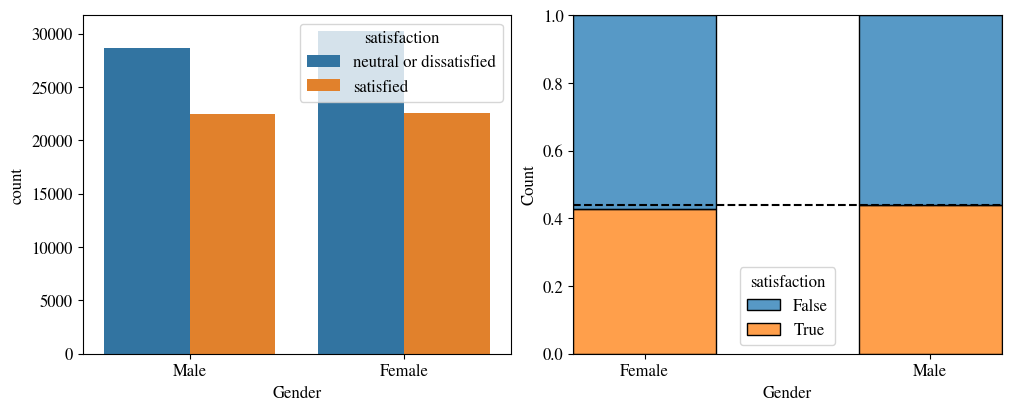

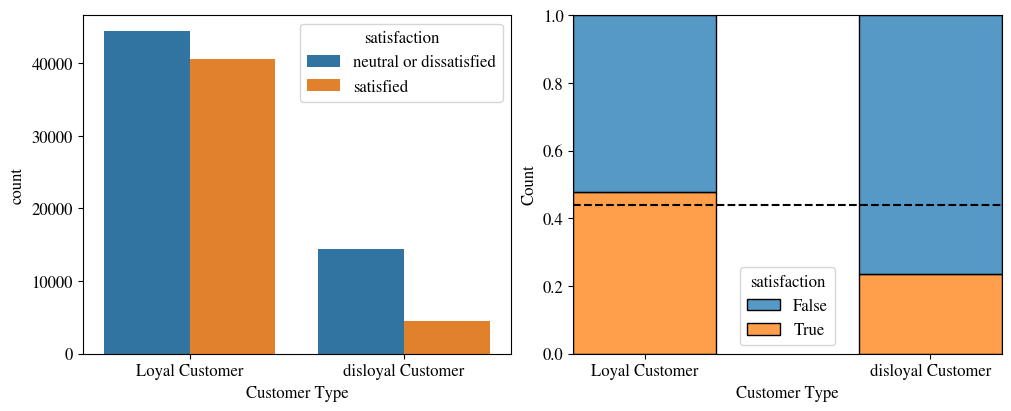

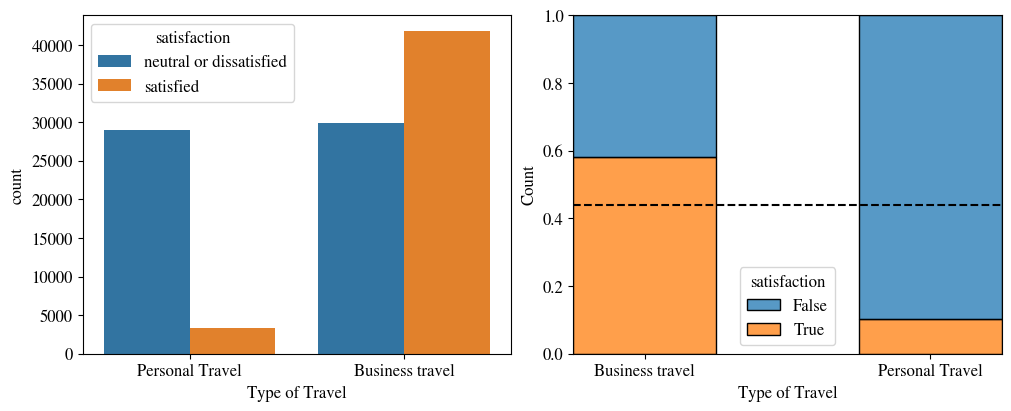

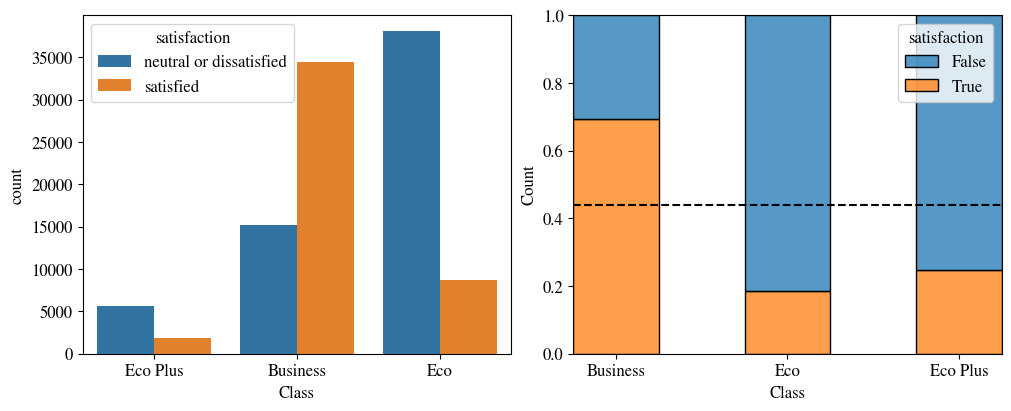

In [20]:
for col in ['Gender', 'Customer Type', 'Type of Travel', 'Class']:
    fig, ax = plt.subplots(figsize=(10, 4), ncols=2, constrained_layout=True)
    sns.countplot(data=data, x=col, hue='satisfaction', ax=ax[0])
    sns.histplot(
        data=df,
        x=col,
        multiple='fill',
        hue='satisfaction',
        discrete=True,
        shrink=0.5,
        ax=ax[1],
    )
    ax[1].axhline(y=satisfied_frac, color='k', linestyle='--')
    plt.show()

Observations:

1. There is a very minimal difference between the male and female satisfaction rates. Rather than relying on this information, particularly as a binary variable, we'll drop this category.

2. Loyal customers tend to have a higher satisfaction rate than disloyal customers.

3. Passengers traveling for business reasons have a significantly higher satisfaction rate than passengers traveling for personal reasons. Passengers traveling for business reasons may have a higher rate of being in business class, or may just be more accustomed to flying.

4. Passengers in business class have a high satisfaction rate compared to passengers in economy or economy plus. Economy plus passengers are only slightly more satisfied than those in economy.

## Correlation Matrix

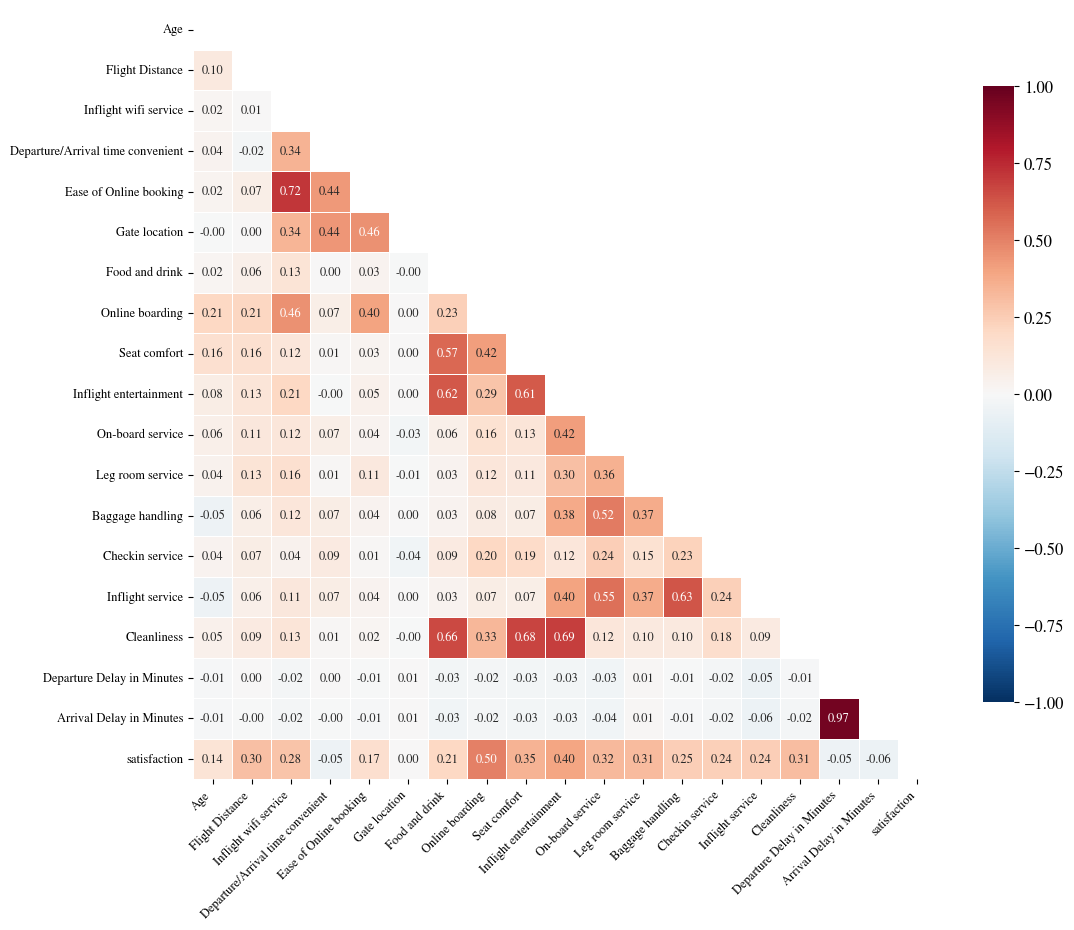

In [21]:
corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    ax=ax,
    cbar_kws={"shrink": 0.8},
    vmin=-1,
    vmax=1,
    lw=0.5,
    linecolor='w',
    annot_kws={"size": 9},
)

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.tick_params(axis='x', labelsize=9)
ax.tick_params(axis='y', labelsize=9)

plt.show()

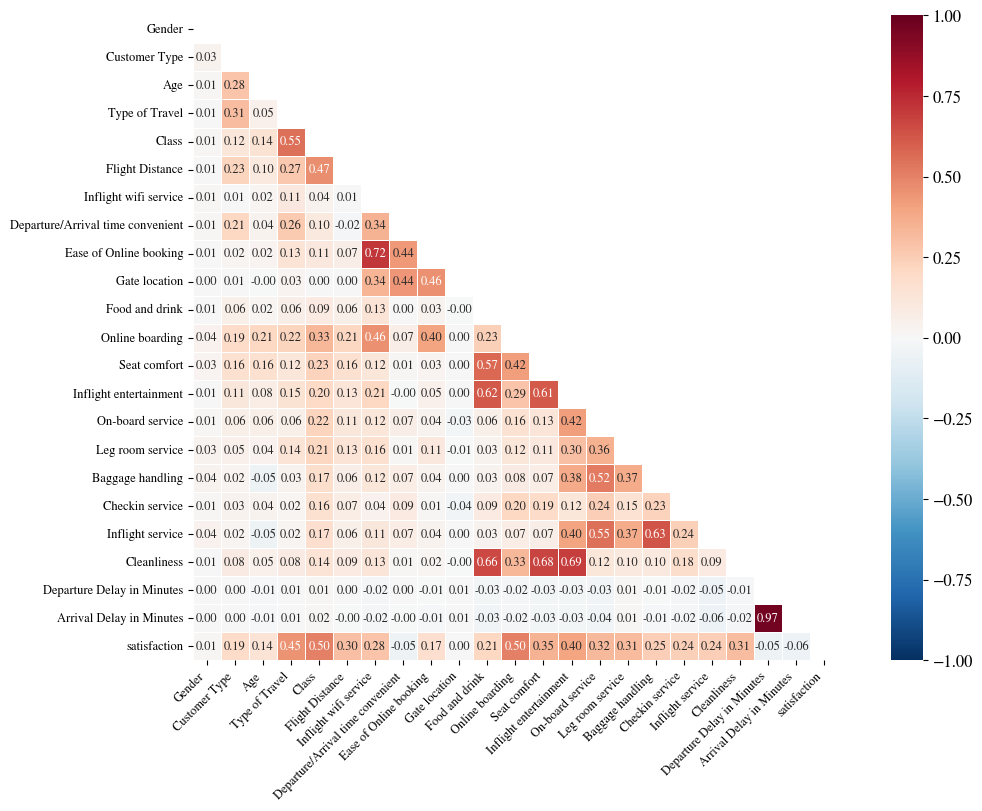

In [22]:
from dython.nominal import associations

results = associations(df, compute_only=True)
corr_matrix = results['corr']
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(12, 8), constrained_layout=True)
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap='RdBu_r',
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
    linecolor='white',
    annot_kws={"size": 9},
)

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.tick_params(axis='x', labelsize=9)
ax.tick_params(axis='y', labelsize=9)

plt.show()

Observations:

1. There is a very strong correlation between departure and arrival delays. If these features are used, we probably only need one of them.

2. There's a fairly strong correlation between ease of online booking and inflight wifi service. These don't initially seem directly related, but it may signal the tech-savviness of customers. Less tech-savvy customers may have troubles with booking tickets online and figuring out how to use inflight wifi, giving them an overall lower satisfaction.

3. There is some correlation among cleanliness, seat comfort, food and drink, and inflight entertainment. This might signal the overall general comfort of customers in the physical airplane space.

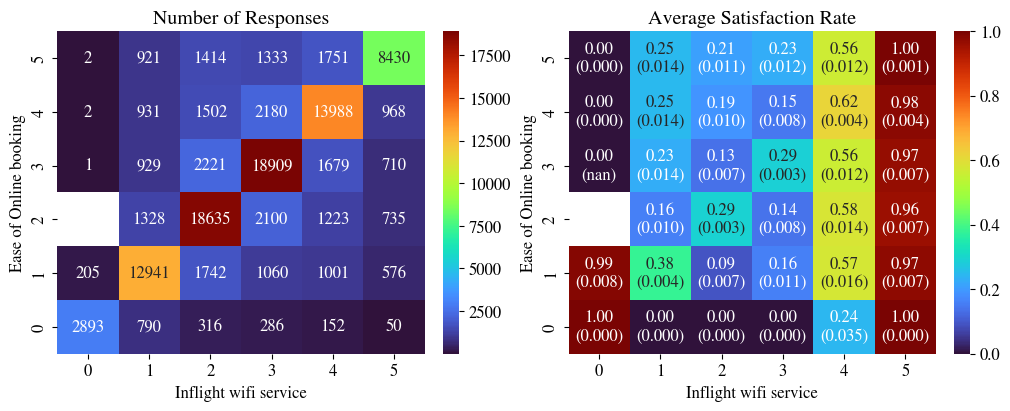

In [23]:
pivot_count = df.pivot_table(
    index='Ease of Online booking',
    columns='Inflight wifi service',
    values='satisfaction',
    aggfunc='count',
)

stats = df.groupby(['Ease of Online booking', 'Inflight wifi service'])[
    'satisfaction'
].agg(['mean', 'sem'])
pivot_mean = stats['mean'].unstack()
pivot_std = stats['sem'].unstack()

annot_labels = (
    pivot_mean.map(lambda x: f"{x:.2f}")
    + "\n("
    + pivot_std.map(lambda x: f"{x:.3f}")
    + ")"
)

fig, ax = plt.subplots(figsize=(10, 4), ncols=2, constrained_layout=True)

sns.heatmap(pivot_count, annot=True, fmt='g', cmap='turbo', ax=ax[0])
ax[0].set_title('Number of Responses')
ax[0].invert_yaxis()

sns.heatmap(pivot_mean, annot=annot_labels, fmt='', cmap='turbo', ax=ax[1])
ax[1].set_title('Average Satisfaction Rate')
ax[1].invert_yaxis()

plt.show()

Observations:

1. Even though ease of online booking and inflight wifi service don't seem to be related, customers tend to rate them the same way (most counts on the diagonal of the left subplot).

2. Inflight wifi service rating has a strong effect on satisfaction rate. When it's rated a 5, satisfaction is nearly perfect regardless of the online booking rating. When wifi rating is a 4, satisfaction is almost always ~0.6 regardless of online booking rating. When wifi rating is below a 4, there is another big dropoff in satisfaction rating.

3. Given the two observations above, it seems that the ease of online booking rating is being affected by the inflight wifi service rating. When wifi service is rated high, customers are satisfied and rate their ease of online booking high as well. When wifi service is rated low, customers are not satisfied and ease of online booking is also rated low. This could still be influenced by the customers' tech savviness, but it could also be customers' prior feelings (their experience when booking) being superceded by their more recent feelings (their experience with the wifi on the flight).

# Making an Initial Model

In [24]:
X = df.drop(columns=['Gender', 'Arrival Delay in Minutes', 'satisfaction'])
y = df['satisfaction']

X_test = df_test.drop(columns=['Gender', 'Arrival Delay in Minutes', 'satisfaction'])
y_test = df_test['satisfaction']

In [25]:
numeric_features = numeric_cols + rated_cols
categorical_features = categorical_cols

numeric_features.remove('Arrival Delay in Minutes')
categorical_features.remove('Gender')

In [26]:
preprocessor = ColumnTransformer(
    [
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='if_binary'), categorical_features),
    ]
)

## Permutation Importance

We'll create a test model to check the permutation importance of each feature. This will check how much the performance of the model is affected relative to its base performance when each feature is shuffled.

In [27]:
clf = Pipeline(
    [
        ('preprocessor', preprocessor),
        ('model', RandomForestClassifier(random_state=99)),
    ]
)
clf.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [28]:
result = permutation_importance(clf, X, y, n_repeats=10, random_state=99, n_jobs=-1)

<Axes: xlabel='mean_importance', ylabel='feature'>

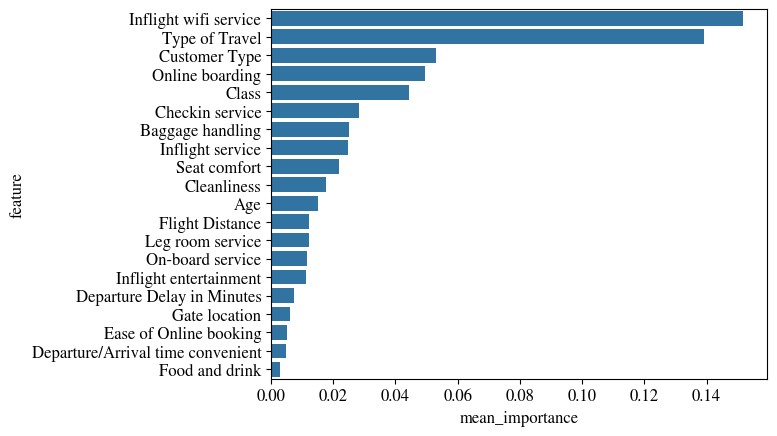

In [29]:
importance_df = (
    pd.DataFrame(
        {
            'feature': X.columns,
            'mean_importance': result.importances_mean,
        }
    )
    .sort_values(by='mean_importance', ascending=False)
    .reset_index(drop=True)
)

sns.barplot(data=importance_df, x='mean_importance', y='feature')

Observations:

1. Type of travel matters a lot, even more than class.

2. Inflight wifi service also matters a lot. Ease of online booking matters little, which may have been expected given that the wifi service rating seemed to determine the ease of online booking rating and satisfaction varied significantly with the wifi service rating.

3. Some features like seat comfort, inflight service, cleanliness, etc. pertain to the physical space of the flight and have similar importances. These could perhaps be combined into a single physical space rating.

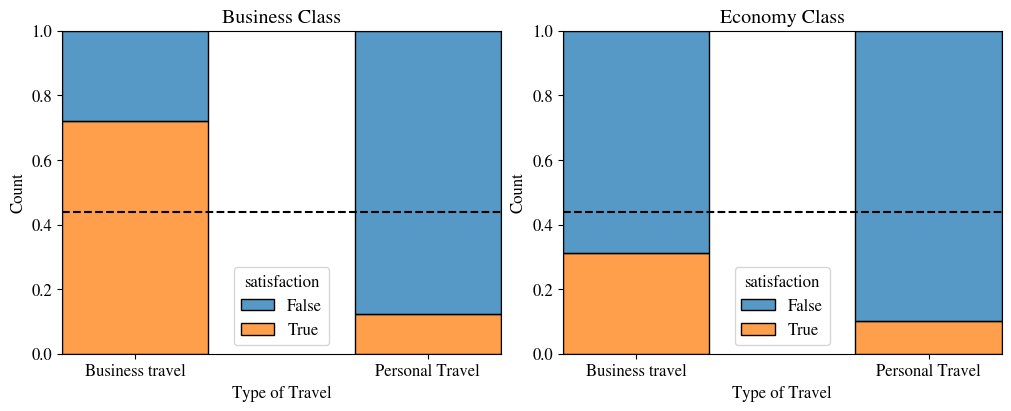

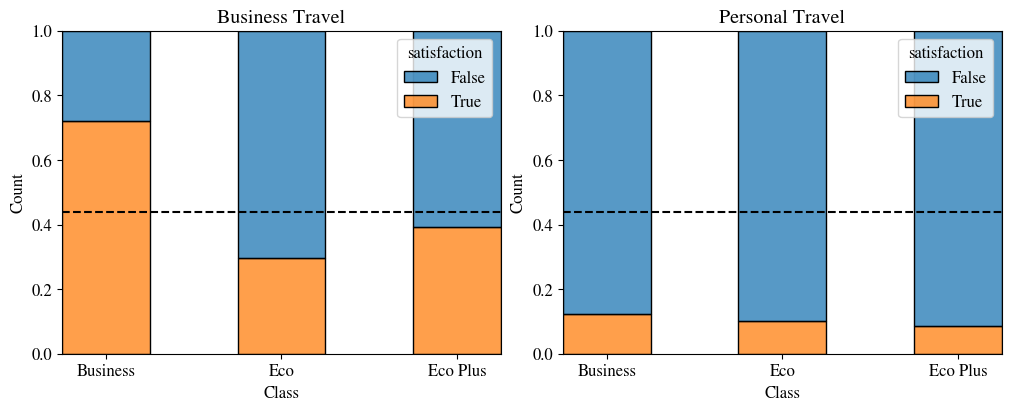

In [30]:
graph_set1 = ('Class', 'Business', 'Type of Travel', 'Business Class', 'Economy Class')
graph_set2 = (
    'Type of Travel',
    'Business travel',
    'Class',
    'Business Travel',
    'Personal Travel',
)

for gset in [graph_set1, graph_set2]:
    group_col, group_cat, divide_col, title1, title2 = gset
    fig, ax = plt.subplots(figsize=(10, 4), ncols=2, constrained_layout=True)
    sns.histplot(
        data=df[df[group_col] == group_cat],
        x=divide_col,
        multiple='fill',
        hue='satisfaction',
        discrete=True,
        shrink=0.5,
        ax=ax[0],
    )
    sns.histplot(
        data=df[df[group_col] != group_cat],
        x=divide_col,
        multiple='fill',
        hue='satisfaction',
        discrete=True,
        shrink=0.5,
        ax=ax[1],
    )
    ax[0].axhline(y=satisfied_frac, color='k', linestyle='--')
    ax[1].axhline(y=satisfied_frac, color='k', linestyle='--')
    ax[0].set_title(title1)
    ax[1].set_title(title2)
    plt.show()

Observations:

1. Type of travel matters a lot. Among passengers flying for personal reasons, satisfaction rates are always low and vary little across different ticket classes.

2. Among passengers who flew in economy class, those traveling for business reasons were generally more satisfied. In business class, the reason for travel makes a huge difference in satisfaction.

## Mutual Information

Mutual information measures how much the uncertainty in the target decreases by knowing the value of each feature. This value is measured in a vacuum for each feature, so interactions are not included.

In [31]:
from sklearn.feature_selection import mutual_info_classif

importances = mutual_info_classif(X, y, discrete_features=True, random_state=99)
feature_mi = pd.Series(importances, index=X.columns).sort_values(ascending=False)
feature_mi

Online boarding                      0.210858
Inflight wifi service                0.161702
Class                                0.133508
Type of Travel                       0.113635
Inflight entertainment               0.093717
Flight Distance                      0.081411
Seat comfort                         0.078879
Leg room service                     0.060730
On-board service                     0.057203
Cleanliness                          0.051827
Ease of Online booking               0.050834
Age                                  0.046166
Baggage handling                     0.042633
Inflight service                     0.040982
Checkin service                      0.031930
Food and drink                       0.026221
Customer Type                        0.018590
Gate location                        0.012023
Departure Delay in Minutes           0.005331
Departure/Arrival time convenient    0.002173
dtype: float64

Observations:

1. Features like Online boarding, Inflight wifi service, Type of Travel, and Class have relatively high MI and were also relatively high in permutation importance.

2. Customer Type has very low MI but had high permutation importance. This suggests that on its own it doesn't have much predictive power, but combined with some other feature(s) it can be useful.

3. Features like Gate Location, Departure Delay in Minutes, and Departure/Arrival time convenient have both low MI and low permutation importance. These features could maybe be dropped.

## Initial Scoring

In [32]:
print('Test Set')
scoring.print_scores(clf, X_test, y_test)
print('\nTraining Set')
scoring.print_scores(clf, X, y)

Test Set
Classification Report
              precision    recall  f1-score   support

       False       0.96      0.98      0.97     14573
        True       0.97      0.94      0.96     11403

    accuracy                           0.96     25976
   macro avg       0.96      0.96      0.96     25976
weighted avg       0.96      0.96      0.96     25976

ROC-AUC Score: 0.9938

Training Set
Classification Report
              precision    recall  f1-score   support

       False       1.00      1.00      1.00     58879
        True       1.00      1.00      1.00     45025

    accuracy                           1.00    103904
   macro avg       1.00      1.00      1.00    103904
weighted avg       1.00      1.00      1.00    103904

ROC-AUC Score: 1.0000


Test Set


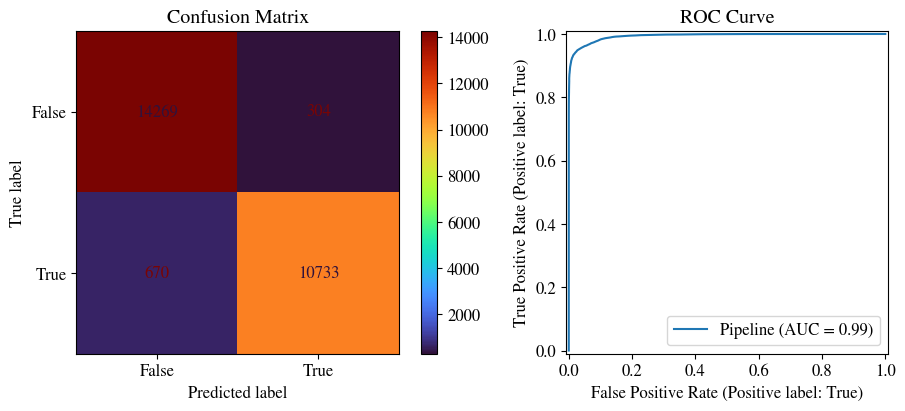

Training Set


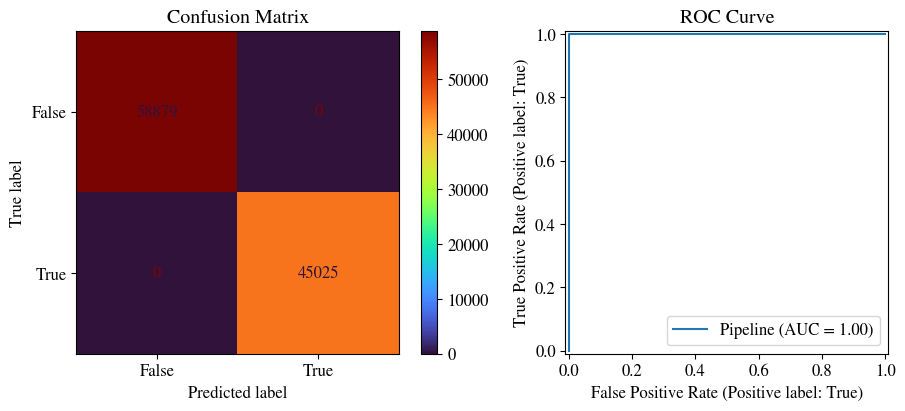

In [33]:
print('Test Set')
scoring.plot_confusion_matrix_roc_auc(clf, X_test, y_test)
print('Training Set')
scoring.plot_confusion_matrix_roc_auc(clf, X, y)

Observations:

1. The model is working near-perfectly on the test set and perfectly on the training set. It would seem this initial model is overfitting.

2. For the next modeling round, we should limit the hyperparameters to get a more generalized model.

# Trying Multiple Models

In [34]:
target = 'satisfaction'

In [35]:
model_ret = pipelines.run_model(
    df,
    df_test,
    target,
    numeric_features,
    categorical_features,
    model.objective,
)
X, y, X_test, y_test, clf, study, preprocessor = model_ret

[I 2026-03-27 14:23:05,573] A new study created in memory with name: no-name-3b98f8bb-f534-4591-a3e0-2c3e49f6db60
[I 2026-03-27 14:23:56,125] Trial 0 finished with value: 0.9905377782043274 and parameters: {'classifier': 'RandomForest', 'n_estimators': 232, 'max_depth': 11, 'min_samples_split': 4}. Best is trial 0 with value: 0.9905377782043274.
[I 2026-03-27 14:23:58,638] Trial 1 finished with value: 0.9815759620651698 and parameters: {'classifier': 'XGBoost', 'n_estimators': 295, 'max_depth': 3, 'learning_rate': 0.013765013291257176, 'subsample': 0.9675735717934119}. Best is trial 0 with value: 0.9905377782043274.
[I 2026-03-27 14:24:14,486] Trial 2 finished with value: 0.9820900033236726 and parameters: {'classifier': 'RandomForest', 'n_estimators': 99, 'max_depth': 7, 'min_samples_split': 14}. Best is trial 0 with value: 0.9905377782043274.
[I 2026-03-27 14:24:35,417] Trial 3 finished with value: 0.97768577369109 and parameters: {'classifier': 'RandomForest', 'n_estimators': 148, '

Best Hyperparameters:
classifier             LightGBM
n_estimators                281
max_depth                     9
learning_rate            0.0435
num_leaves                   83

Best Score: 0.9951


Test Set
Classification Report
              precision    recall  f1-score   support

       False       0.96      0.98      0.97     14573
        True       0.98      0.94      0.96     11403

    accuracy                           0.96     25976
   macro avg       0.97      0.96      0.96     25976
weighted avg       0.97      0.96      0.96     25976

ROC-AUC Score: 0.9954

Training Set
Classification Report
              precision    recall  f1-score   support

       False       0.97      0.99      0.98     58879
        True       0.98      0.96      0.97     45025

    accuracy                           0.97    103904
   macro avg       0.98      0.97      0.97    103904
weighted avg       0.97      0.97      0.97    103904

ROC-AUC Score: 0.9981

Test Set


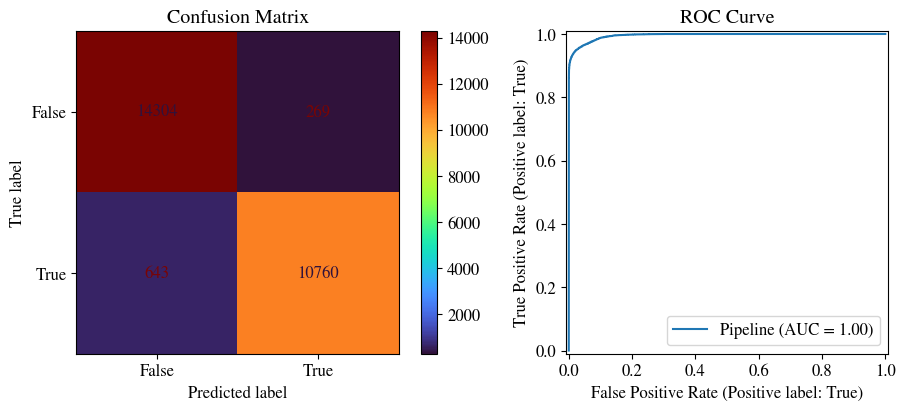

Training Set


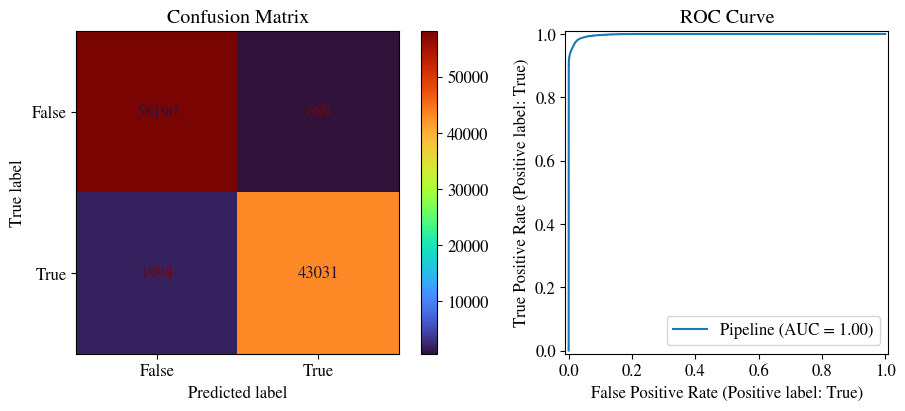

In [36]:
pipelines.score_model(*model_ret)

Observations:

1. The best model is still performing suspiciously well. We'll try shuffling the target variables to see if the model is still powerful enough to learn the noise in the data.

In [37]:
pipelines.score_model(*model_ret, shuffle=True, plot_roc=False)

Test Set
Classification Report
              precision    recall  f1-score   support

       False       0.56      0.95      0.70     14573
        True       0.38      0.04      0.07     11403

    accuracy                           0.55     25976
   macro avg       0.47      0.49      0.39     25976
weighted avg       0.48      0.55      0.43     25976

ROC-AUC Score: 0.4790

Training Set
Classification Report
              precision    recall  f1-score   support

       False       0.60      0.99      0.75     58879
        True       0.92      0.14      0.24     45025

    accuracy                           0.62    103904
   macro avg       0.76      0.57      0.50    103904
weighted avg       0.74      0.62      0.53    103904

ROC-AUC Score: 0.7688


The model is getting an AUC of around 0.48 on the test set, which makes sense given that the targets were shuffled. On the training set, it's still achieving an AUC of 0.77, meaning it's overfitting the training data. The model hyperparameters need to be more constrained.

# Restricting Model Hyperparameter Ranges

Here we'll use a restricted objective function for optuna.

In [38]:
model_ret = pipelines.run_model(
    df,
    df_test,
    target,
    numeric_features,
    categorical_features,
    model.objective_restricted,
)
X, y, X_test, y_test, clf, study, preprocessor = model_ret

[I 2026-03-27 14:24:58,019] A new study created in memory with name: no-name-efdf8a55-d680-40a1-880a-1bc17f8cbbdf
[I 2026-03-27 14:25:26,935] Trial 0 finished with value: 0.9774650630408924 and parameters: {'classifier': 'RandomForest', 'n_estimators': 206, 'max_depth': 6, 'min_samples_leaf': 40}. Best is trial 0 with value: 0.9774650630408924.
[I 2026-03-27 14:25:27,928] Trial 1 finished with value: 0.9747251867396651 and parameters: {'classifier': 'XGBoost', 'n_estimators': 97, 'max_depth': 3, 'learning_rate': 0.019970282336917375, 'subsample': 0.7466129028078755}. Best is trial 0 with value: 0.9774650630408924.
[I 2026-03-27 14:25:55,084] Trial 2 finished with value: 0.9775196258632904 and parameters: {'classifier': 'RandomForest', 'n_estimators': 195, 'max_depth': 6, 'min_samples_leaf': 30}. Best is trial 2 with value: 0.9775196258632904.
[I 2026-03-27 14:26:20,091] Trial 3 finished with value: 0.9729308013673998 and parameters: {'classifier': 'RandomForest', 'n_estimators': 205, '

Best Hyperparameters:
classifier             LightGBM
n_estimators                193
max_depth                     5
learning_rate            0.0807
num_leaves                   44
min_child_samples            36

Best Score: 0.9942


## Scoring

Test Set
Classification Report
              precision    recall  f1-score   support

       False       0.95      0.98      0.97     14573
        True       0.97      0.94      0.96     11403

    accuracy                           0.96     25976
   macro avg       0.96      0.96      0.96     25976
weighted avg       0.96      0.96      0.96     25976

ROC-AUC Score: 0.9943

Training Set
Classification Report
              precision    recall  f1-score   support

       False       0.96      0.98      0.97     58879
        True       0.97      0.94      0.96     45025

    accuracy                           0.96    103904
   macro avg       0.97      0.96      0.96    103904
weighted avg       0.96      0.96      0.96    103904

ROC-AUC Score: 0.9951

Test Set


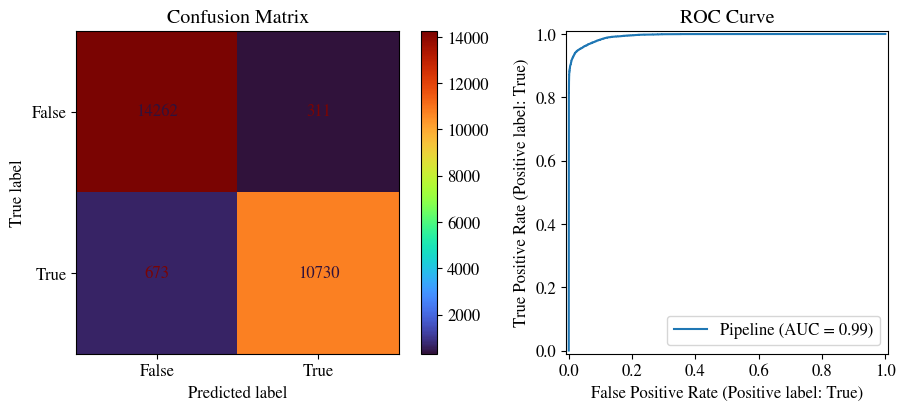

Training Set


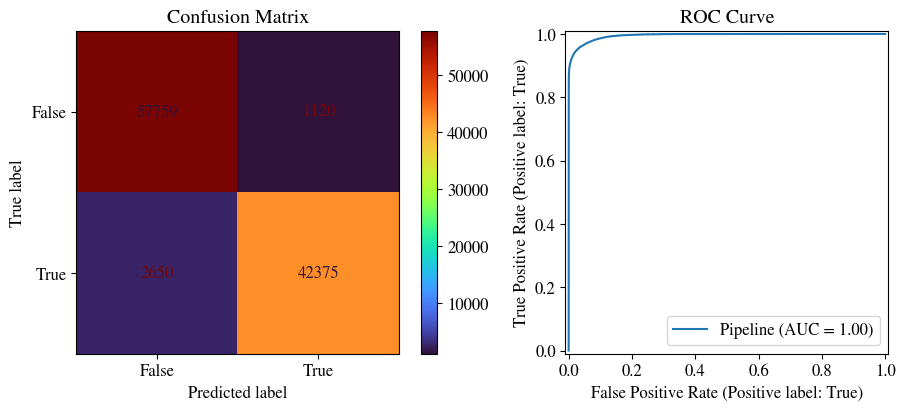

In [39]:
pipelines.score_model(*model_ret)

## Shuffled Scoring

In [40]:
pipelines.score_model(*model_ret, shuffle=True, plot_roc=False)

Test Set
Classification Report
              precision    recall  f1-score   support

       False       0.56      0.97      0.71     14573
        True       0.36      0.02      0.04     11403

    accuracy                           0.55     25976
   macro avg       0.46      0.50      0.37     25976
weighted avg       0.47      0.55      0.41     25976

ROC-AUC Score: 0.4751

Training Set
Classification Report
              precision    recall  f1-score   support

       False       0.58      0.99      0.73     58879
        True       0.79      0.05      0.09     45025

    accuracy                           0.58    103904
   macro avg       0.68      0.52      0.41    103904
weighted avg       0.67      0.58      0.45    103904

ROC-AUC Score: 0.6295


The AUC for the shuffled training data has dropped significantly to 0.63. This shows that the model is definitely less complex and not able to find patterns as easily within the noise of the data. This could be generalized further to get closer to the theoretical AUC of 0.5.

We can check which features are important in the model and perhaps generalize or group some of them.

## SHAP Values

 97%|=================== | 4828/5000 [00:15<00:00]       

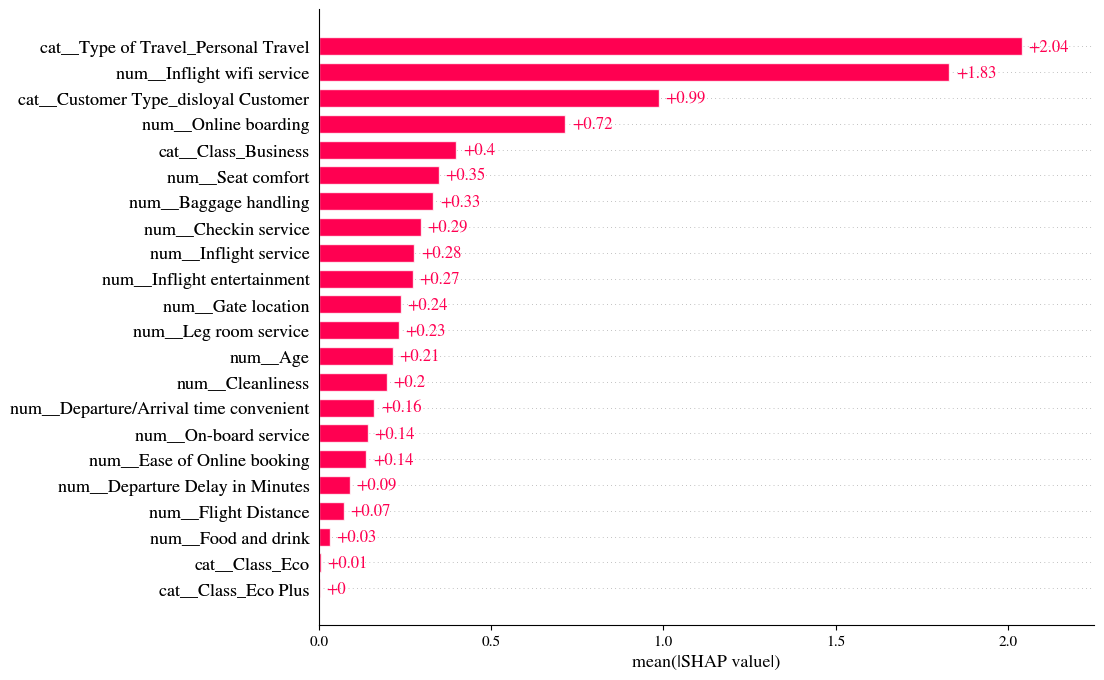

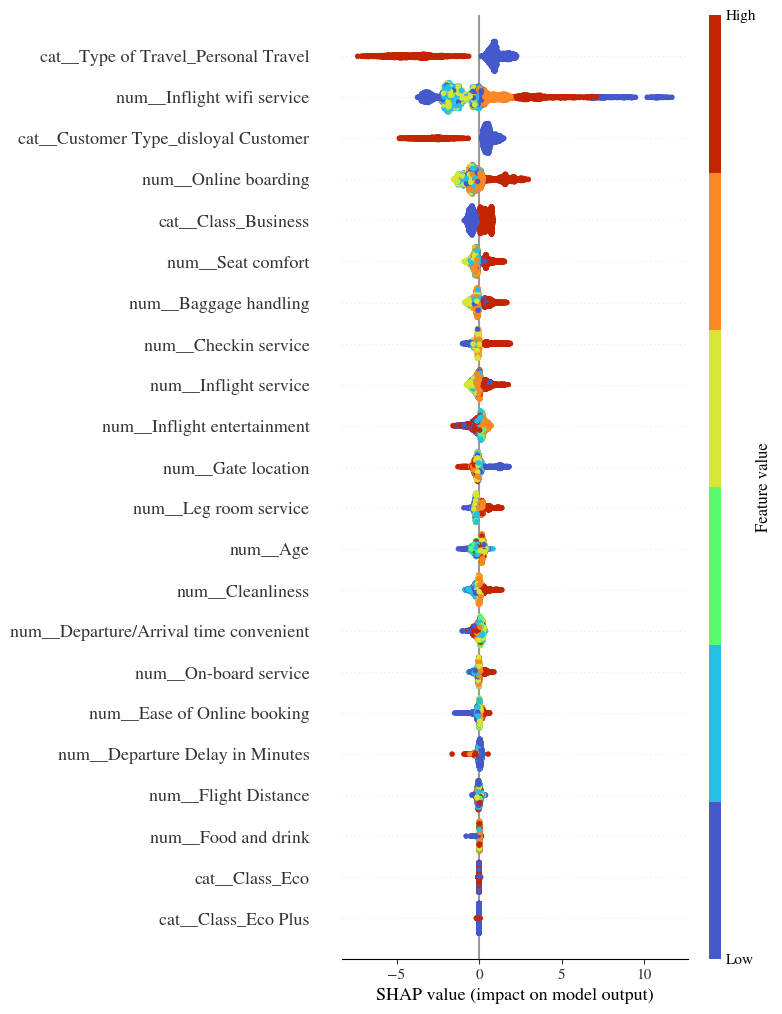

In [41]:
shap_values = pipelines.plot_model_shap_values(X, clf)

Observations:

1. Customers who rate the inflight wifi service as a 0 are appearing on both ends of the SHAP spectrum. I suspect that 0 is not really 0 and is instead "N/A".

2. Economy and Economy Plus contribute almost nothing to the model. What's really is important is whether or not the passenger is in business class. This feature could be reduced to business or non-business.

3. Flight distance doesn't appear to affect passenger satisfaction much. This feature could probably be dropped.

Inspect the passengers who rated wifi service a 0.

In [42]:
wifi_zero_df = df[df['Inflight wifi service'] == 0]

print('Satisfaction for wifi 0:')
print(wifi_zero_df['satisfaction'].value_counts())

print('\nBreakdown by Travel Type and Class:')
print('\n', wifi_zero_df['Type of Travel'].value_counts())
print('\n', wifi_zero_df['Class'].value_counts())
print('\n', pd.crosstab(wifi_zero_df['Type of Travel'], wifi_zero_df['Class']))
print('\n', wifi_zero_df['Customer Type'].value_counts())

Satisfaction for wifi 0:
satisfaction
True     3095
False       8
Name: count, dtype: int64

Breakdown by Travel Type and Class:

 Type of Travel
Business travel    2452
Personal Travel     651
Name: count, dtype: int64

 Class
Business    1979
Eco          929
Eco Plus     195
Name: count, dtype: int64

 Class            Business  Eco  Eco Plus
Type of Travel                          
Business travel      1926  392       134
Personal Travel        53  537        61

 Customer Type
Loyal Customer       2410
disloyal Customer     693
Name: count, dtype: int64


Passengers who rated wifi service a 0 tended to be flying in business class for business reasons and were loyal customers. These passengers might be frequent flyers who don't rely on wifi to occupy themselves. This may be a legitimate passenger demographic, but given that a 0 rating is (likely) "N/A", it could correspond to many different reasons. We'll let the model infer this type of passenger based on other features and instead replace 0s with 3s to try to prevent overfitting.

# Modifying the Features

Replace 0 ratings with 3s to put them at a more neutral value where they won't impact the model as much.

In [43]:
df = processing.replace_survey_zeros(df, rated_cols=rated_cols)
df_test = processing.replace_survey_zeros(df_test, rated_cols=rated_cols)

Replace the "Class" feature with "business_class" which only checks if a passenger is in business class or not.

In [44]:
df = processing.add_business_class_feature(df)
df_test = processing.add_business_class_feature(df_test)

## Rerunning the Models

Update the features lists to reflect changes that were made. Remove flight distance and flight time convenience as they contribute little to the model and don't show much color separation in the beeswarm plot.

In [45]:
categorical_features.append('business_class')
categorical_features.remove('Class')

numeric_features.remove('Flight Distance')
numeric_features.remove('Departure/Arrival time convenient')

In [46]:
model_ret = pipelines.run_model(
    df,
    df_test,
    target,
    numeric_features,
    categorical_features,
    model.objective_restricted,
)
X, y, X_test, y_test, clf, study, preprocessor = model_ret

[I 2026-03-27 14:27:06,122] A new study created in memory with name: no-name-c90522ca-2347-43b8-bc0f-0f8a55deddb0
[I 2026-03-27 14:27:27,159] Trial 0 finished with value: 0.9676049450027712 and parameters: {'classifier': 'RandomForest', 'n_estimators': 161, 'max_depth': 6, 'min_samples_leaf': 28}. Best is trial 0 with value: 0.9676049450027712.
[I 2026-03-27 14:27:33,591] Trial 1 finished with value: 0.9611081601879767 and parameters: {'classifier': 'RandomForest', 'n_estimators': 54, 'max_depth': 5, 'min_samples_leaf': 46}. Best is trial 0 with value: 0.9676049450027712.
[I 2026-03-27 14:27:35,608] Trial 2 finished with value: 0.9731762354121105 and parameters: {'classifier': 'XGBoost', 'n_estimators': 272, 'max_depth': 4, 'learning_rate': 0.012402426747544078, 'subsample': 0.7627410167420433}. Best is trial 2 with value: 0.9731762354121105.
[I 2026-03-27 14:27:37,681] Trial 3 finished with value: 0.9638692048572984 and parameters: {'classifier': 'XGBoost', 'n_estimators': 151, 'max_d

Best Hyperparameters:
classifier              XGBoost
n_estimators                268
max_depth                     6
learning_rate            0.0555
subsample                0.7847

Best Score: 0.9889


## Scoring

Test Set
Classification Report
              precision    recall  f1-score   support

       False       0.94      0.98      0.96     14573
        True       0.97      0.92      0.95     11403

    accuracy                           0.95     25976
   macro avg       0.96      0.95      0.95     25976
weighted avg       0.95      0.95      0.95     25976

ROC-AUC Score: 0.9892

Training Set
Classification Report
              precision    recall  f1-score   support

       False       0.94      0.98      0.96     58879
        True       0.98      0.92      0.95     45025

    accuracy                           0.96    103904
   macro avg       0.96      0.95      0.96    103904
weighted avg       0.96      0.96      0.96    103904

ROC-AUC Score: 0.9919

Test Set


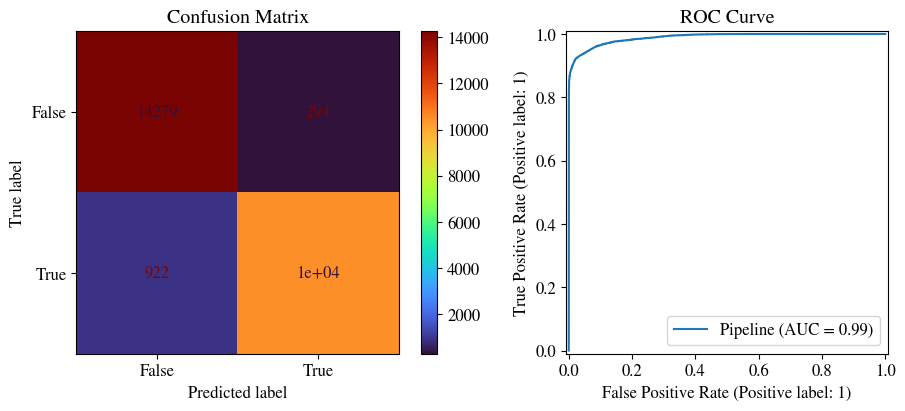

Training Set


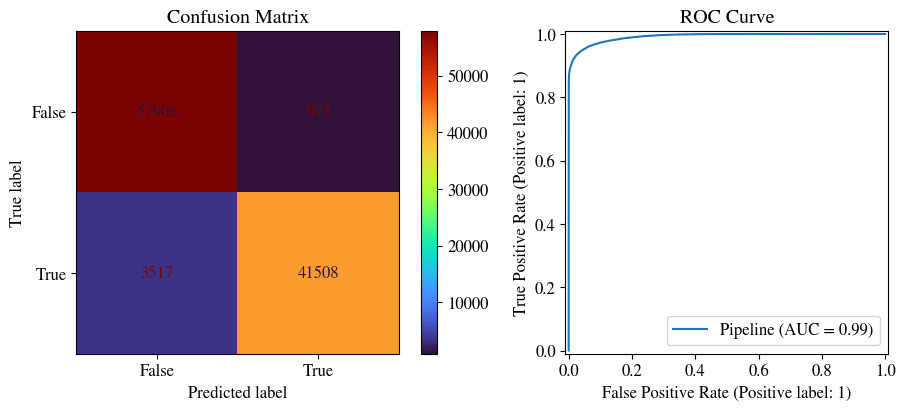

In [47]:
pipelines.score_model(*model_ret)

## Shuffled Scoring

In [48]:
pipelines.score_model(*model_ret, shuffle=True, plot_roc=False)

Test Set
Classification Report
              precision    recall  f1-score   support

       False       0.56      0.94      0.70     14573
        True       0.34      0.04      0.07     11403

    accuracy                           0.55     25976
   macro avg       0.45      0.49      0.38     25976
weighted avg       0.46      0.55      0.42     25976

ROC-AUC Score: 0.4723

Training Set
Classification Report
              precision    recall  f1-score   support

       False       0.59      0.98      0.74     58879
        True       0.83      0.11      0.19     45025

    accuracy                           0.60    103904
   macro avg       0.71      0.55      0.47    103904
weighted avg       0.69      0.60      0.50    103904

ROC-AUC Score: 0.6886


The model still scores very highly with an AUC of around 0.98 on both the training and test sets. The shuffled AUC for the training set has gone up to 0.69. Reducing complexity might help bring this back down.

## SHAP Values

 99%|===================| 4947/5000 [00:41<00:00]        

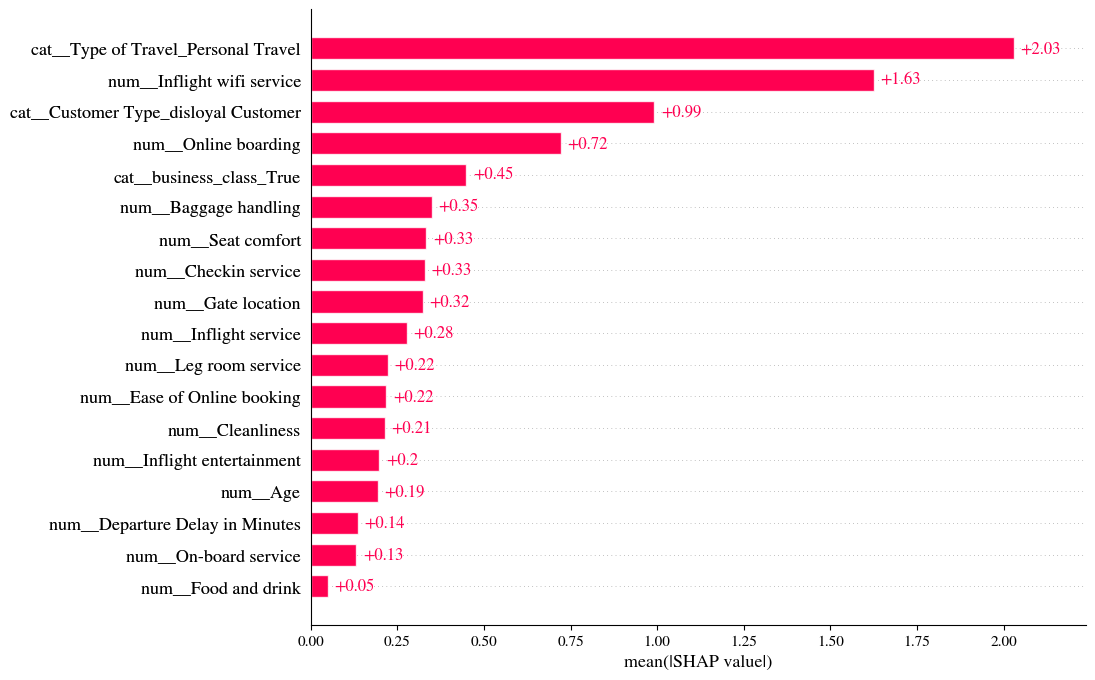

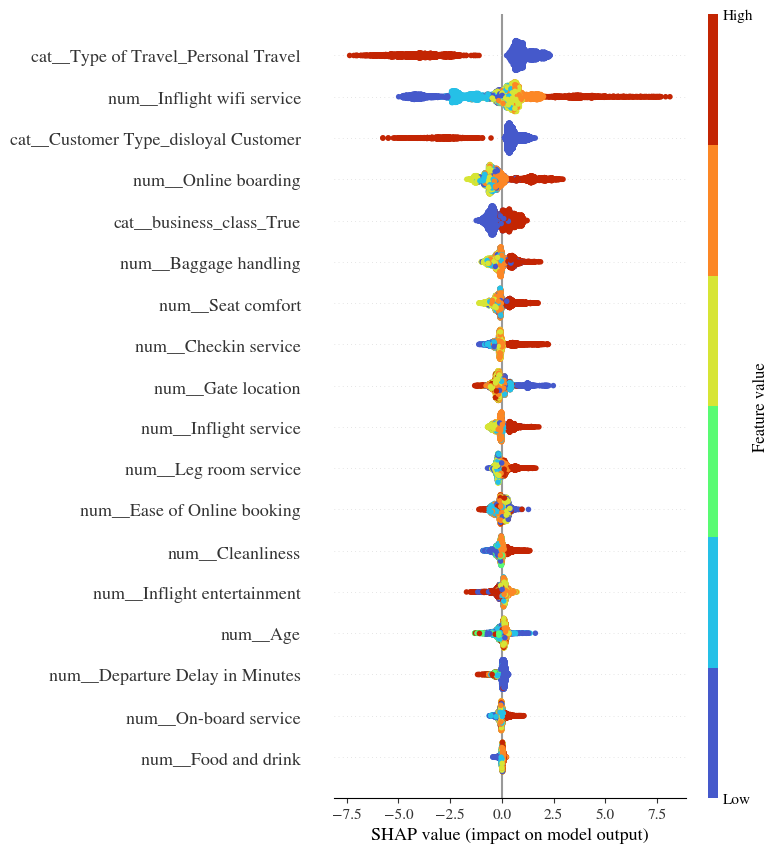

In [49]:
shap_values = pipelines.plot_model_shap_values(X, clf)

Observations:

1. The business class feature is working well and shows a clear division between its two options.

2. The bottom 5 features don't have strong impacts on the model output and generally don't have a clear color trend. Dropping these could reduce model complexity and help with overfitting.

# Dropping Low-SHAP Features

In [50]:
X_processed = clf.named_steps['preprocessor'].transform(X)

shap_df = (
    pd.DataFrame(
        {
            'feature': X_processed.columns,
            'mean_abs_shap': np.abs(shap_values.values).mean(axis=0),
        }
    )
    .sort_values(by='mean_abs_shap', ascending=False)
    .reset_index(drop=True)
)

shap_df.iloc[-5:]

,feature,mean_abs_shap
13,num__Inflight entertainment,0.197534
14,num__Age,0.193461
15,num__Departure Delay in Minutes,0.135419
16,num__On-board service,0.131094
17,num__Food and drink,0.048771


In [51]:
drop_features = [
    'Food and drink',
    'Departure Delay in Minutes',
    'Age',
    'Ease of Online booking',
    'Gate location',
]

numeric_features = [f for f in numeric_features if f not in drop_features]

## Retraining

In [52]:
model_ret = pipelines.run_model(
    df,
    df_test,
    target,
    numeric_features,
    categorical_features,
    model.objective_restricted,
)
X, y, X_test, y_test, clf, study, preprocessor = model_ret

[I 2026-03-27 14:29:01,829] A new study created in memory with name: no-name-0fd6979b-729c-4e0e-b067-cd4986a7be9d
[I 2026-03-27 14:29:14,872] Trial 0 finished with value: 0.9616728556434013 and parameters: {'classifier': 'RandomForest', 'n_estimators': 157, 'max_depth': 5, 'min_samples_leaf': 26}. Best is trial 0 with value: 0.9616728556434013.
[I 2026-03-27 14:29:17,072] Trial 1 finished with value: 0.9798945103700516 and parameters: {'classifier': 'XGBoost', 'n_estimators': 296, 'max_depth': 4, 'learning_rate': 0.02878977834465847, 'subsample': 0.7339032796035201}. Best is trial 1 with value: 0.9798945103700516.
[I 2026-03-27 14:29:18,436] Trial 2 finished with value: 0.9758325304275102 and parameters: {'classifier': 'LightGBM', 'n_estimators': 124, 'max_depth': 5, 'learning_rate': 0.026670001522606547, 'num_leaves': 30, 'min_child_samples': 37}. Best is trial 1 with value: 0.9798945103700516.
[I 2026-03-27 14:29:23,625] Trial 3 finished with value: 0.9451437687447306 and parameters:

Best Hyperparameters:
classifier              XGBoost
n_estimators                194
max_depth                     6
learning_rate            0.0352
subsample                0.6129

Best Score: 0.9830


## Scoring

Test Set
Classification Report
              precision    recall  f1-score   support

       False       0.92      0.97      0.95     14573
        True       0.96      0.90      0.93     11403

    accuracy                           0.94     25976
   macro avg       0.94      0.94      0.94     25976
weighted avg       0.94      0.94      0.94     25976

ROC-AUC Score: 0.9833

Training Set
Classification Report
              precision    recall  f1-score   support

       False       0.93      0.97      0.95     58879
        True       0.96      0.90      0.93     45025

    accuracy                           0.94    103904
   macro avg       0.94      0.94      0.94    103904
weighted avg       0.94      0.94      0.94    103904

ROC-AUC Score: 0.9843

Test Set


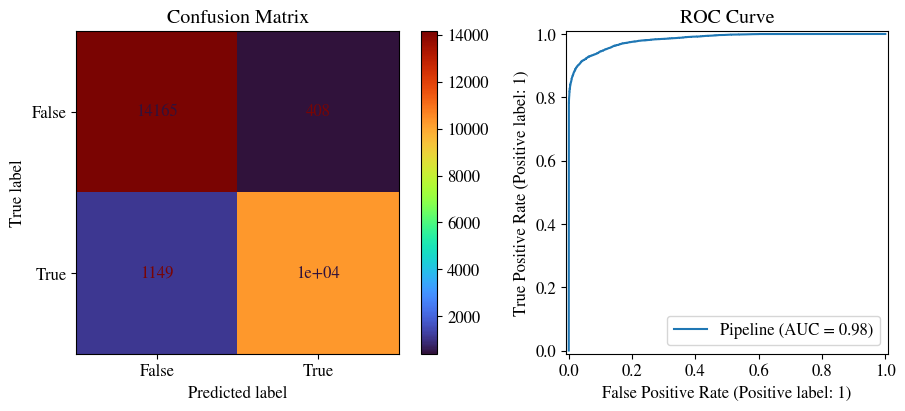

Training Set


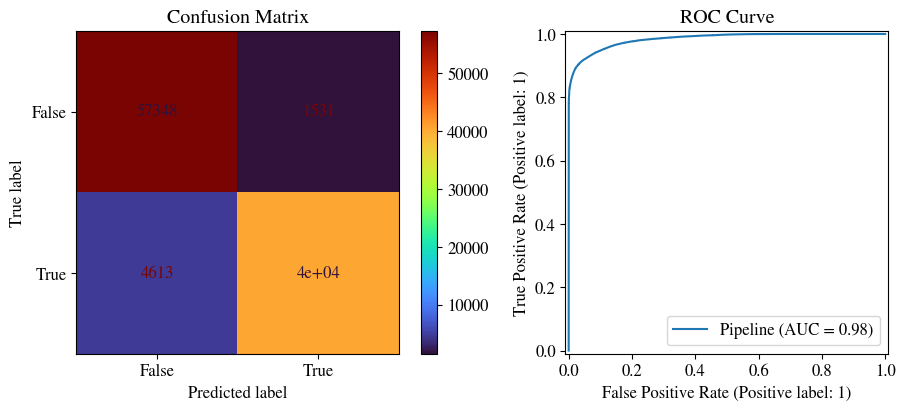

In [53]:
pipelines.score_model(*model_ret)

## Shuffled Scoring

In [54]:
pipelines.score_model(*model_ret, shuffle=True, plot_roc=False)

Test Set
Classification Report
              precision    recall  f1-score   support

       False       0.56      0.98      0.71     14573
        True       0.43      0.02      0.03     11403

    accuracy                           0.56     25976
   macro avg       0.50      0.50      0.37     25976
weighted avg       0.50      0.56      0.42     25976

ROC-AUC Score: 0.4586

Training Set
Classification Report
              precision    recall  f1-score   support

       False       0.57      0.99      0.73     58879
        True       0.76      0.04      0.07     45025

    accuracy                           0.58    103904
   macro avg       0.67      0.51      0.40    103904
weighted avg       0.65      0.58      0.44    103904

ROC-AUC Score: 0.6080


The shuffled AUC for the training set is still higher than we would like. To generalize a model some more, we can combine some of the similar features. This removes granularity in inspecting how individual aspects of the overall flight experience affect passengers, but it should help make a model that's better applicable to future data.

## SHAP Values

 98%|===================| 4886/5000 [00:22<00:00]        

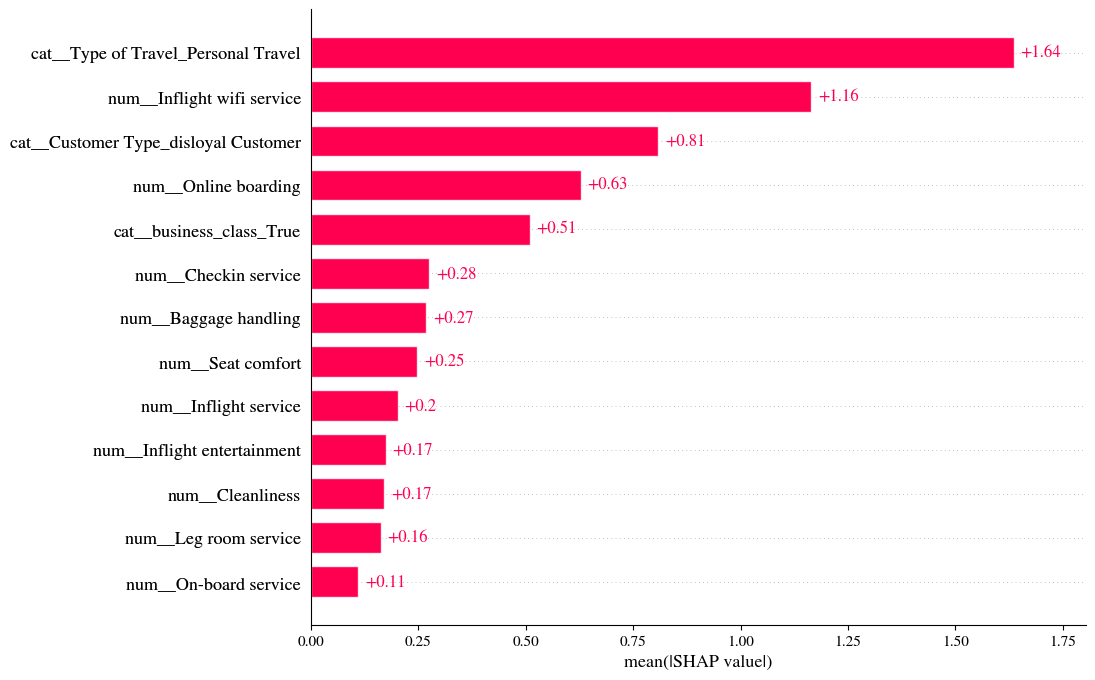

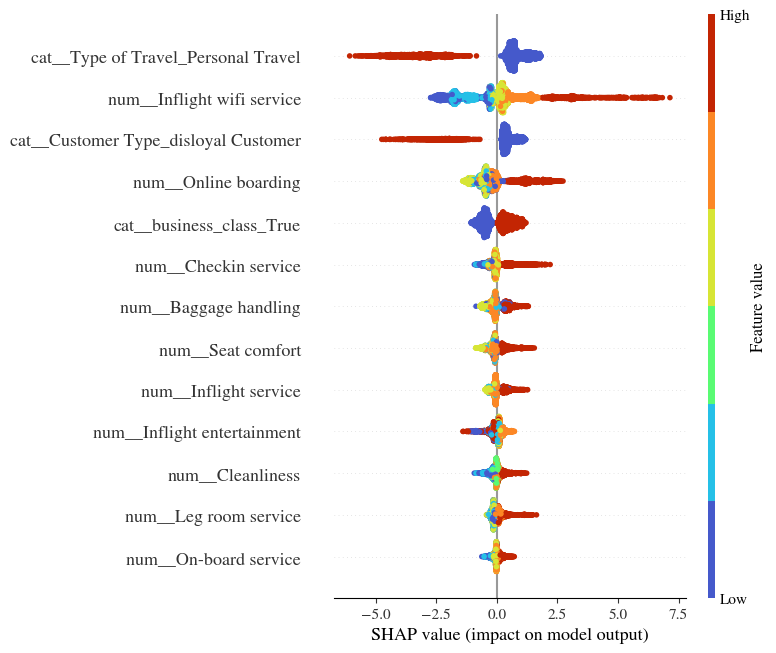

In [55]:
shap_values = pipelines.plot_model_shap_values(X, clf)

The bottom 8 features are a step down in SHAP compared to the higher features. We can group these into something that captures the cabin experience and something that captures the service.

- **cabin_rating**: Seat comfort, Inflight entertainment, Leg room service, Cleanliness
- **service_rating**: Baggage handling, Inflight service, Checkin service, On-board service

# Combining Features

In [56]:
cabin_cols = [
    'Seat comfort',
    'Inflight entertainment',
    'Leg room service',
    'Cleanliness',
]
service_cols = [
    'Baggage handling',
    'Inflight service',
    'Checkin service',
    'On-board service',
]
df = processing.add_cabin_rating_feature(df, cabin_cols=cabin_cols)
df_test = processing.add_cabin_rating_feature(df_test, cabin_cols=cabin_cols)

df = processing.add_service_rating_feature(df, service_cols=service_cols)
df_test = processing.add_service_rating_feature(df_test, service_cols=service_cols)

In [57]:
for f in cabin_cols + service_cols:
    numeric_features.remove(f)

numeric_features.append('cabin_rating')
numeric_features.append('service_rating')

## Retraining

In [58]:
model_ret = pipelines.run_model(
    df,
    df_test,
    target,
    numeric_features,
    categorical_features,
    model.objective_restricted,
)
X, y, X_test, y_test, clf, study, preprocessor = model_ret

[I 2026-03-27 14:30:18,548] A new study created in memory with name: no-name-1c97252e-e127-4de4-8030-3ba097aae4c6
[I 2026-03-27 14:30:20,692] Trial 0 finished with value: 0.9759107782968461 and parameters: {'classifier': 'LightGBM', 'n_estimators': 278, 'max_depth': 6, 'learning_rate': 0.1695653962210025, 'num_leaves': 38, 'min_child_samples': 41}. Best is trial 0 with value: 0.9759107782968461.
[I 2026-03-27 14:30:30,318] Trial 1 finished with value: 0.9489683679641825 and parameters: {'classifier': 'RandomForest', 'n_estimators': 196, 'max_depth': 3, 'min_samples_leaf': 34}. Best is trial 0 with value: 0.9759107782968461.
[I 2026-03-27 14:30:31,377] Trial 2 finished with value: 0.9688863207371903 and parameters: {'classifier': 'LightGBM', 'n_estimators': 131, 'max_depth': 4, 'learning_rate': 0.028519821783763635, 'num_leaves': 33, 'min_child_samples': 43}. Best is trial 0 with value: 0.9759107782968461.
[I 2026-03-27 14:30:32,486] Trial 3 finished with value: 0.9690514841496094 and p

Best Hyperparameters:
classifier             LightGBM
n_estimators                158
max_depth                     5
learning_rate            0.1849
num_leaves                   42
min_child_samples            31

Best Score: 0.9761


## Scoring

Test Set
Classification Report
              precision    recall  f1-score   support

       False       0.92      0.96      0.94     14573
        True       0.94      0.89      0.91     11403

    accuracy                           0.93     25976
   macro avg       0.93      0.92      0.92     25976
weighted avg       0.93      0.93      0.93     25976

ROC-AUC Score: 0.9766

Training Set
Classification Report
              precision    recall  f1-score   support

       False       0.92      0.96      0.94     58879
        True       0.94      0.89      0.91     45025

    accuracy                           0.93    103904
   macro avg       0.93      0.92      0.93    103904
weighted avg       0.93      0.93      0.93    103904

ROC-AUC Score: 0.9784

Test Set


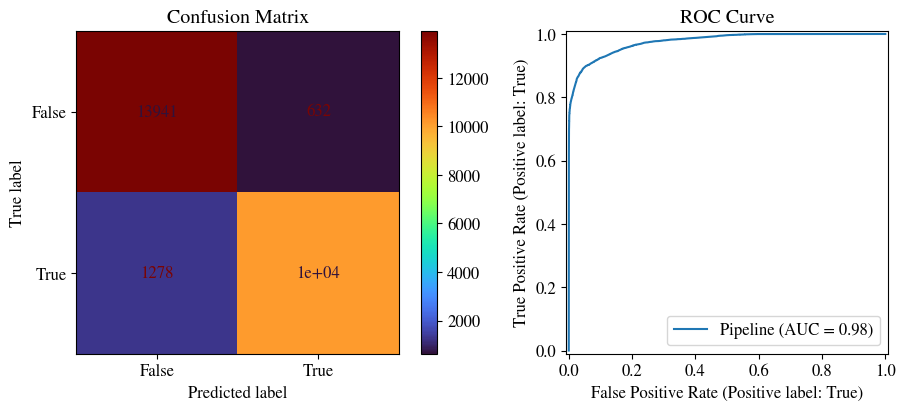

Training Set


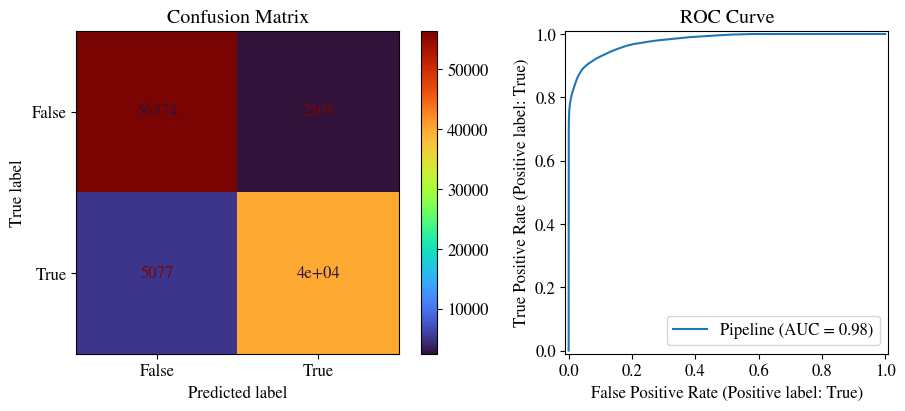

In [59]:
pipelines.score_model(*model_ret)

## Shuffled Scoring

In [60]:
pipelines.score_model(*model_ret, shuffle=True, plot_roc=False)

Test Set
Classification Report
              precision    recall  f1-score   support

       False       0.56      0.95      0.70     14573
        True       0.36      0.04      0.07     11403

    accuracy                           0.55     25976
   macro avg       0.46      0.49      0.38     25976
weighted avg       0.47      0.55      0.42     25976

ROC-AUC Score: 0.4650

Training Set
Classification Report
              precision    recall  f1-score   support

       False       0.58      0.97      0.72     58879
        True       0.61      0.06      0.12     45025

    accuracy                           0.58    103904
   macro avg       0.59      0.52      0.42    103904
weighted avg       0.59      0.58      0.46    103904

ROC-AUC Score: 0.5727


## SHAP Values

 96%|=================== | 4824/5000 [00:13<00:00]       

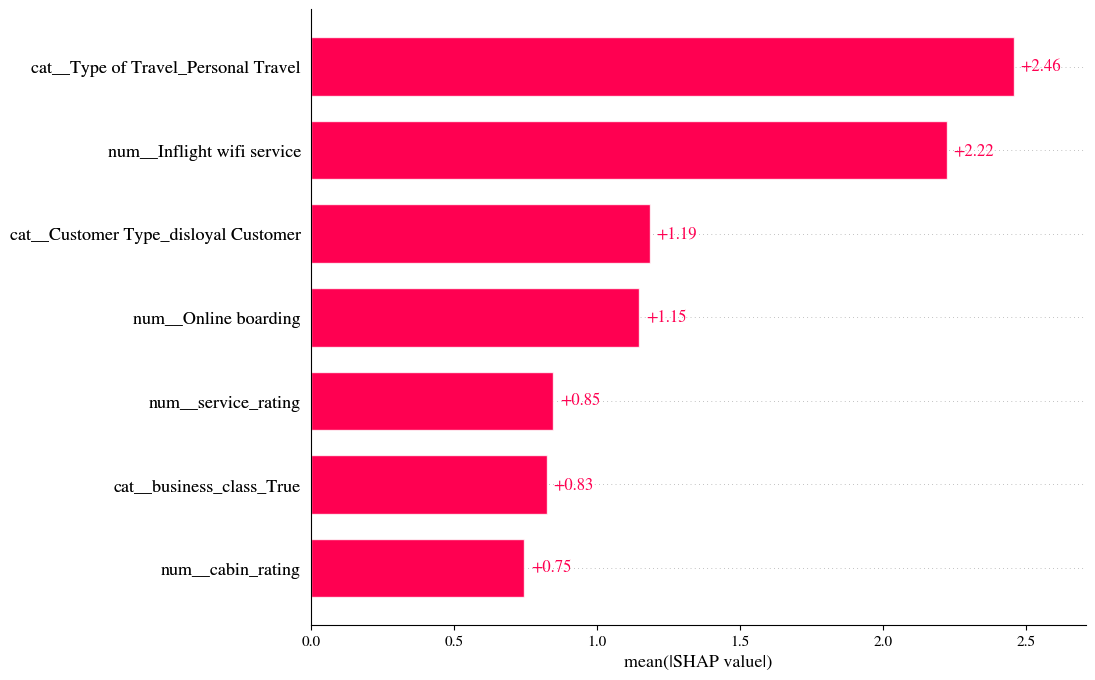

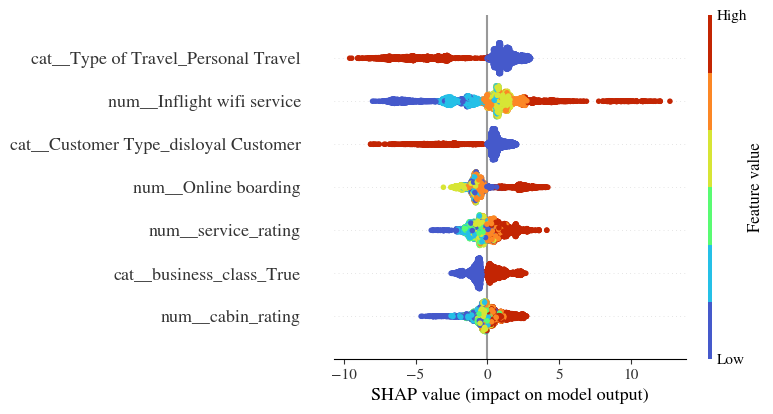

In [61]:
shap_values = pipelines.plot_model_shap_values(X, clf)

## Partial Dependence

### One-dimensional

The partial dependence looks at how the predicted probability of passenger satisfaction changes as an individual feature value changes.

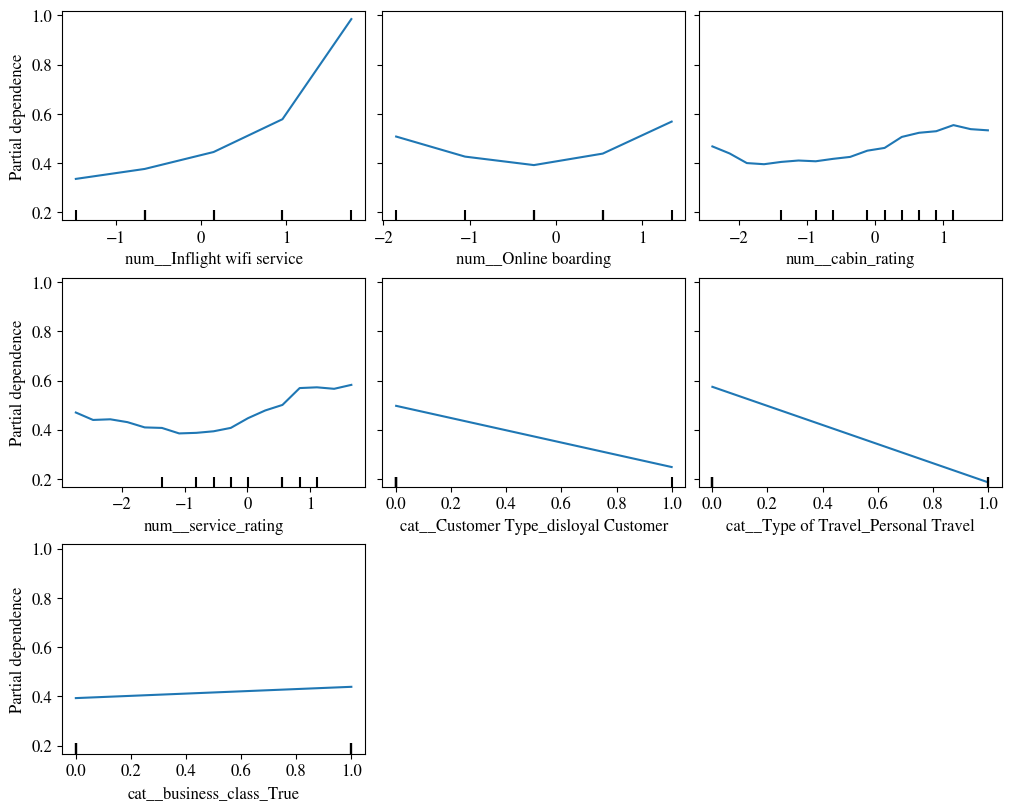

In [75]:
clf_model = clf.named_steps['model']
X_processed = clf.named_steps['preprocessor'].transform(X)

fig, ax = plt.subplots(figsize=(10, 8), constrained_layout=True)
PartialDependenceDisplay.from_estimator(
    clf_model, X_processed, X_processed.columns, ax=ax
)
plt.show()

Observations:

1. The difference between low and high wifi ratings is very large. The jump from 4 to 5 is even larger than the jump from 1 to 4. Providing the best wifi service possible to try to get more 5 ratings could lead to a big improvement in satisfaction.

2. Passenger type of travel also makes a big difference on satisfaction. Passengers who are traveling for personal reasons are basically starting in a satisfaction debt that other factors would need to make up for.

### Two-dimensional

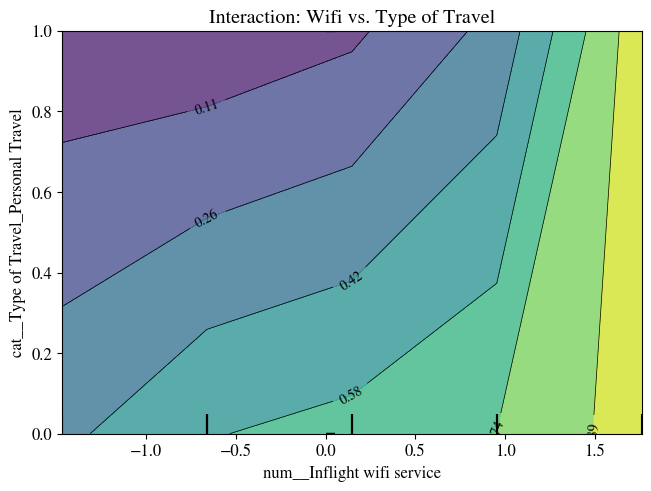

In [76]:
features_to_plot = [
    ('num__Inflight wifi service', 'cat__Type of Travel_Personal Travel')
]

fig, ax = plt.subplots(constrained_layout=True)
PartialDependenceDisplay.from_estimator(
    clf_model, X_processed, features_to_plot, ax=ax, grid_resolution=20
)
plt.title("Interaction: Wifi vs. Type of Travel")
plt.show()

Having a moderate-to-high wifi service is generally sufficient to get passengers traveling for business reasons into a higher satisfaction probability. For passengers traveling for personal reasons, the wifi service needs to be substantially higher to get them to the same level of satisfaction probability.

### Personal vs Business Traveler SHAP Values

How do the feature SHAP values compare for personal and business travelers?

In [ ]:
X_sample = X_processed.sample(5000, random_state=99)
explainer = shap.Explainer(clf_model, X_sample)
shap_values = explainer(X_sample)

 98%|===================| 4910/5000 [00:13<00:00]        

                                feature  personal_shap  business_shap
0   cat__Type of Travel_Personal Travel       4.890519       1.288976
1            num__Inflight wifi service       3.077322       1.813776
2              cat__business_class_True       0.902171       0.788648
3                  num__Online boarding       0.679620       1.373123
4  cat__Customer Type_disloyal Customer       0.476243       1.526646
5                   num__service_rating       0.412559       1.057468
6                     num__cabin_rating       0.351199       0.936828


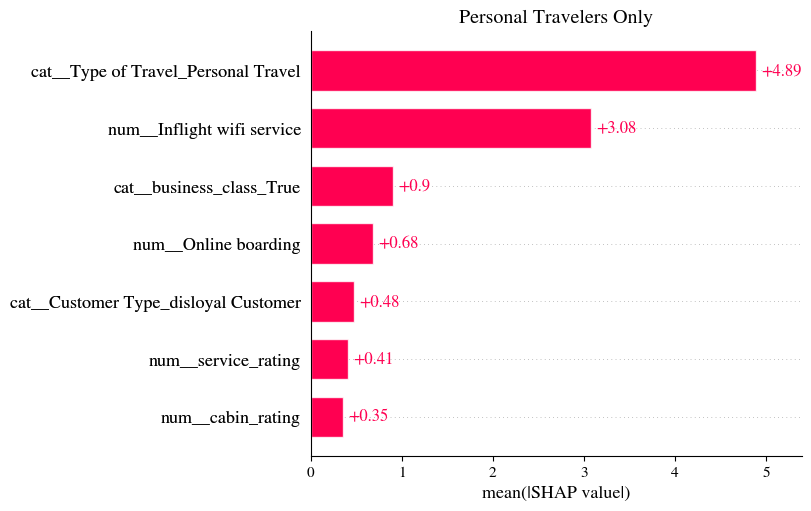

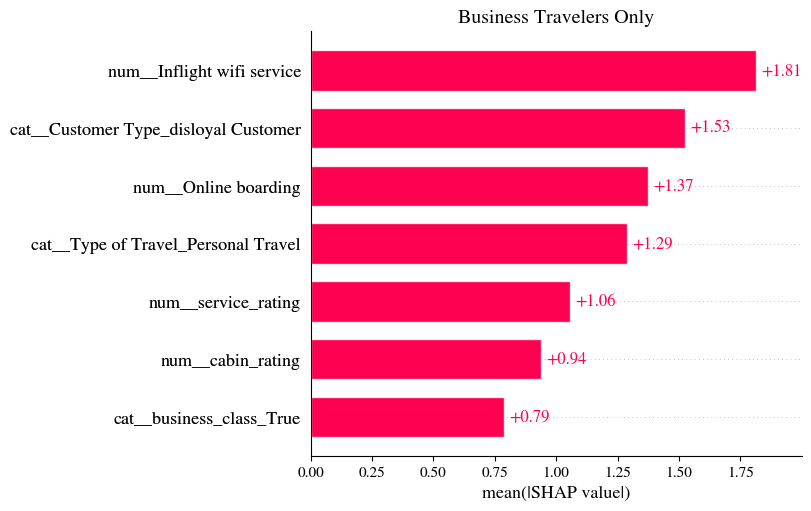

In [ ]:
is_personal = (X_sample['cat__Type of Travel_Personal Travel'] == 1).values

personal_shap = shap_values[is_personal, :]
business_shap = shap_values[~is_personal, :]

shap_df = (
    pd.DataFrame(
        {
            'feature': X_sample.columns,
            'personal_shap': np.abs(personal_shap.values).mean(axis=0),
            'business_shap': np.abs(business_shap.values).mean(axis=0),
        }
    )
    .sort_values(by='personal_shap', ascending=False)
    .reset_index(drop=True)
)
print(shap_df)

fig, ax = plt.subplots(figsize=(10, 4), constrained_layout=True)
ax.set_title('Personal Travelers Only')
shap.plots.bar(personal_shap)

fig, ax = plt.subplots(figsize=(10, 4), constrained_layout=True)
ax.set_title('Business Travelers Only')
shap.plots.bar(business_shap)
plt.show()

There is a stark contrast in breakdown between passengers traveling for personal and business reasons. Personal travelers are dominated by the fact that they are traveling for personal reasons. Other factors have little impact on their satisfaction outside of the wifi service. Even moving them to business class has low impact. Business travelers have a much more broad set of impacting factors. While they also care about the wifi service, factors like online boarding and the general cabin and service ratings also have a fair impact on their satisfaction.

Ultimately, it seems like passenger satisfaction likely comes down to money and the value of that money. Business travelers are likely not paying their own airfare, whereas personal travelers are paying hundreds of dollars for an experience they don't see as great value. There's likely no amount of improvement in cleanliness or inflight service that will move the needle for these passengers. It would take something that increases the value of the price paid to fly to improve their satisfaction.